# Final Project — One Anomaly, Defended

**Curso:** IELE756 — Preparación y Análisis de Datos  

**Equipo:** Fernando Rodríguez y Gaspar Lämmel; Grupo 17

**Repositorio GitHub:** https://github.com/gsprlmml-create/iele756-region-XX

**Video:**  https://youtu.be/VTZm6_9YhJU

## Anomalía defendida

San Pedro presenta una tasa ENO observada muy superior a la tasa predicha por el modelo Negative Binomial, convirtiéndose en el mayor residuo positivo del análisis comunal de la Región Metropolitana.

In [1]:
# ============================================================
# PARTE 0: SETUP, RUTAS Y CARGA DE DATOS PROCESADOS
# PROYECTO FINAL — GRUPO 17
# ============================================================

# ------------------------------------------------------------
# Instalación mínima
# ------------------------------------------------------------

%pip install -q openpyxl scipy

# ------------------------------------------------------------
# Montaje de Google Drive
# ------------------------------------------------------------

from google.colab import drive
drive.mount("/content/drive")

# ------------------------------------------------------------
# Librerías
# ------------------------------------------------------------

import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from IPython.display import display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 11

# ------------------------------------------------------------
# Datos formales del equipo
# ------------------------------------------------------------

GROUP_NUMBER_FERN = "Grupo 17"
TEAM_NAMES_FERN = "Fernando Rodríguez y Gaspar Lammel"

GITHUB_REPO_URL_FERN = "PENDIENTE: pegar link del repositorio GitHub antes de entregar"
VIDEO_URL_FERN = "PENDIENTE: pegar link del video antes de entregar"

# ------------------------------------------------------------
# Rutas principales
# ------------------------------------------------------------

RUTA_BASE_FERN = Path("/content/drive/MyDrive/ColabNotebooks")
RUTA_OUTPUT_TAREA3_FERN = RUTA_BASE_FERN / "output"

RUTA_FINAL_FERN = RUTA_BASE_FERN / "final_project_fern"
RUTA_FINAL_FIGS_FERN = RUTA_FINAL_FERN / "figs"
RUTA_FINAL_OUTPUTS_FERN = RUTA_FINAL_FERN / "outputs"
RUTA_FINAL_DATA_FERN = RUTA_FINAL_FERN / "data"
RUTA_FINAL_TABLAS_FERN = RUTA_FINAL_FERN / "tablas_defensa"
RUTA_FINAL_FIGS_DEFENSA_FERN = RUTA_FINAL_FERN / "figs_defensa"

for ruta_fern in [
    RUTA_FINAL_FERN,
    RUTA_FINAL_FIGS_FERN,
    RUTA_FINAL_OUTPUTS_FERN,
    RUTA_FINAL_DATA_FERN,
    RUTA_FINAL_TABLAS_FERN,
    RUTA_FINAL_FIGS_DEFENSA_FERN
]:
    ruta_fern.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Parámetros de la anomalía
# ------------------------------------------------------------

CODIGO_ANOMALIA_FERN = 13505
NOMBRE_ANOMALIA_FERN = "SAN PEDRO"

REGION_ANOMALIA_FERN = "Región Metropolitana de Santiago"
PROVINCIA_ANOMALIA_FERN = "Provincia de Melipilla"
TIPO_TERRITORIO_ANOMALIA_FERN = "comuna periférica/rural"

# ------------------------------------------------------------
# Funciones auxiliares
# ------------------------------------------------------------

def normalizar_columna_fern(columna_fern):
    columna_fern = str(columna_fern).strip().lower()

    reemplazos_fern = {
        "á": "a",
        "é": "e",
        "í": "i",
        "ó": "o",
        "ú": "u",
        "ñ": "n"
    }

    for original_fern, nuevo_fern in reemplazos_fern.items():
        columna_fern = columna_fern.replace(original_fern, nuevo_fern)

    columna_fern = re.sub(r"[^a-z0-9]+", "_", columna_fern)
    columna_fern = re.sub(r"_+", "_", columna_fern).strip("_")

    return columna_fern


def normalizar_columnas_fern(df_fern):
    df_fern = df_fern.copy()
    df_fern.columns = [normalizar_columna_fern(c) for c in df_fern.columns]
    return df_fern


def leer_csv_robusto_fern(ruta_fern):
    intentos_fern = [
        {"sep": ",", "encoding": "utf-8"},
        {"sep": ";", "encoding": "utf-8"},
        {"sep": ",", "encoding": "latin1"},
        {"sep": ";", "encoding": "latin1"}
    ]

    ultimo_error_fern = None

    for kwargs_fern in intentos_fern:
        try:
            df_fern = pd.read_csv(ruta_fern, **kwargs_fern)
            df_fern = normalizar_columnas_fern(df_fern)

            if df_fern.shape[1] >= 2:
                return df_fern

        except Exception as error_fern:
            ultimo_error_fern = error_fern

    raise ValueError(f"No se pudo leer el archivo: {ruta_fern}. Último error: {ultimo_error_fern}")


def buscar_archivo_fern(nombres_posibles_fern, rutas_busqueda_fern):
    for ruta_base_fern in rutas_busqueda_fern:
        for nombre_fern in nombres_posibles_fern:
            ruta_candidata_fern = ruta_base_fern / nombre_fern

            if ruta_candidata_fern.exists():
                return ruta_candidata_fern

    raise FileNotFoundError(
        "No se encontró ninguno de estos archivos: "
        + ", ".join(nombres_posibles_fern)
    )


def detectar_columna_fern(df_fern, candidatos_fern):
    for columna_fern in candidatos_fern:
        if columna_fern in df_fern.columns:
            return columna_fern

    return None


def preparar_codigo_comuna_fern(df_fern):
    df_fern = df_fern.copy()

    if "codigo_comuna" in df_fern.columns:
        df_fern["codigo_comuna"] = pd.to_numeric(df_fern["codigo_comuna"], errors="coerce")
        df_fern = df_fern.dropna(subset=["codigo_comuna"]).copy()
        df_fern["codigo_comuna"] = df_fern["codigo_comuna"].astype(int)

    if "nombre_comuna" in df_fern.columns:
        df_fern["nombre_comuna"] = (
            df_fern["nombre_comuna"]
            .astype(str)
            .str.strip()
            .str.upper()
            .replace({"NAN": np.nan})
        )

    return df_fern


def formatear_numero_fern(valor_fern, decimales_fern=2):
    if pd.isna(valor_fern):
        return "no disponible"

    return f"{valor_fern:.{decimales_fern}f}"


# ------------------------------------------------------------
# Búsqueda de archivos procesados de Tarea 3
# ------------------------------------------------------------

rutas_busqueda_fern = [
    RUTA_OUTPUT_TAREA3_FERN,
    RUTA_BASE_FERN,
    RUTA_FINAL_OUTPUTS_FERN,
    RUTA_FINAL_DATA_FERN
]

RUTA_ANALITICA_FERN = buscar_archivo_fern(
    [
        "tarea3_analytical_table_rm_final.csv",
        "tarea3_analytical_table.csv"
    ],
    rutas_busqueda_fern
)

RUTA_PREDICCIONES_FERN = buscar_archivo_fern(
    [
        "tarea3_eno_predictions_residuals.csv",
        "tarea3_model_predictions_residuals.csv"
    ],
    rutas_busqueda_fern
)

RUTA_RESIDUOS_EXTREMOS_FERN = buscar_archivo_fern(
    [
        "tarea3_eno_residual_extremes.csv"
    ],
    rutas_busqueda_fern
)

RUTA_IRR_ENO_FERN = buscar_archivo_fern(
    [
        "tarea3_primary_eno_irr.csv",
        "tarea3_negative_binomial_eno_irr.csv"
    ],
    rutas_busqueda_fern
)

# ------------------------------------------------------------
# Carga de tablas
# ------------------------------------------------------------

df_analitica_fern = leer_csv_robusto_fern(RUTA_ANALITICA_FERN)
df_pred_fern = leer_csv_robusto_fern(RUTA_PREDICCIONES_FERN)
df_residuos_extremos_fern = leer_csv_robusto_fern(RUTA_RESIDUOS_EXTREMOS_FERN)
df_irr_eno_fern = leer_csv_robusto_fern(RUTA_IRR_ENO_FERN)

df_analitica_fern = preparar_codigo_comuna_fern(df_analitica_fern)
df_pred_fern = preparar_codigo_comuna_fern(df_pred_fern)
df_residuos_extremos_fern = preparar_codigo_comuna_fern(df_residuos_extremos_fern)

# ------------------------------------------------------------
# Detección de columnas clave
# ------------------------------------------------------------

COL_ENO_TOTAL_FERN = detectar_columna_fern(
    df_pred_fern,
    [
        "eno_total",
        "total_eno",
        "n_eno",
        "eno_count"
    ]
)

COL_OBS_RATE_FERN = detectar_columna_fern(
    df_pred_fern,
    [
        "obs_rate_eno_per_10k",
        "eno_rate_per_10k",
        "observed_rate_eno_per_10k"
    ]
)

COL_PRED_RATE_FERN = detectar_columna_fern(
    df_pred_fern,
    [
        "pred_rate_eno_per_10k",
        "predicted_rate_eno_per_10k"
    ]
)

COL_PRED_COUNT_FERN = detectar_columna_fern(
    df_pred_fern,
    [
        "pred_count_eno",
        "predicted_count_eno"
    ]
)

COL_RESID_FERN = detectar_columna_fern(
    df_pred_fern,
    [
        "pearson_resid_eno",
        "resid_pearson_eno",
        "pearson_residual_eno"
    ]
)

if COL_ENO_TOTAL_FERN is None:
    raise ValueError("No se encontró columna de conteo ENO.")

if COL_PRED_RATE_FERN is None:
    raise ValueError("No se encontró columna de tasa ENO predicha.")

if COL_RESID_FERN is None:
    raise ValueError("No se encontró columna de residuo Pearson ENO.")

if COL_OBS_RATE_FERN is None:
    if {"pop_total", COL_ENO_TOTAL_FERN}.issubset(df_pred_fern.columns):
        df_pred_fern["obs_rate_eno_per_10k"] = (
            10000
            * pd.to_numeric(df_pred_fern[COL_ENO_TOTAL_FERN], errors="coerce")
            / pd.to_numeric(df_pred_fern["pop_total"], errors="coerce")
        )
        COL_OBS_RATE_FERN = "obs_rate_eno_per_10k"
    else:
        raise ValueError("No existe tasa observada ENO ni datos suficientes para reconstruirla.")

# ------------------------------------------------------------
# Conversión numérica de columnas clave
# ------------------------------------------------------------

columnas_numericas_pred_fern = [
    COL_ENO_TOTAL_FERN,
    COL_OBS_RATE_FERN,
    COL_PRED_RATE_FERN,
    COL_PRED_COUNT_FERN,
    COL_RESID_FERN,
    "pop_total"
]

for columna_fern in columnas_numericas_pred_fern:
    if columna_fern is not None and columna_fern in df_pred_fern.columns:
        df_pred_fern[columna_fern] = pd.to_numeric(df_pred_fern[columna_fern], errors="coerce")

# ------------------------------------------------------------
# Control inicial de carga
# ------------------------------------------------------------

df_control_carga_fern = pd.DataFrame([
    {
        "tabla": "tabla_analitica_rm",
        "ruta": str(RUTA_ANALITICA_FERN),
        "filas": df_analitica_fern.shape[0],
        "columnas": df_analitica_fern.shape[1]
    },
    {
        "tabla": "predicciones_residuos_eno",
        "ruta": str(RUTA_PREDICCIONES_FERN),
        "filas": df_pred_fern.shape[0],
        "columnas": df_pred_fern.shape[1]
    },
    {
        "tabla": "residuos_extremos_eno",
        "ruta": str(RUTA_RESIDUOS_EXTREMOS_FERN),
        "filas": df_residuos_extremos_fern.shape[0],
        "columnas": df_residuos_extremos_fern.shape[1]
    },
    {
        "tabla": "irr_modelo_eno",
        "ruta": str(RUTA_IRR_ENO_FERN),
        "filas": df_irr_eno_fern.shape[0],
        "columnas": df_irr_eno_fern.shape[1]
    }
])

df_columnas_clave_fern = pd.DataFrame([
    {"rol": "conteo_eno", "columna": COL_ENO_TOTAL_FERN},
    {"rol": "tasa_eno_observada_10k", "columna": COL_OBS_RATE_FERN},
    {"rol": "tasa_eno_predicha_10k", "columna": COL_PRED_RATE_FERN},
    {"rol": "conteo_eno_predicho", "columna": COL_PRED_COUNT_FERN},
    {"rol": "residuo_pearson_eno", "columna": COL_RESID_FERN}
])

display(df_control_carga_fern)
display(df_columnas_clave_fern)

print("Parte 0 ejecutada correctamente.")

Mounted at /content/drive


,tabla,ruta,filas,columnas
0,tabla_analitica_rm,/content/drive/MyDrive/ColabNotebooks/output/t...,44,50
1,predicciones_residuos_eno,/content/drive/MyDrive/ColabNotebooks/output/t...,36,13
2,residuos_extremos_eno,/content/drive/MyDrive/ColabNotebooks/output/t...,36,8
3,irr_modelo_eno,/content/drive/MyDrive/ColabNotebooks/output/t...,5,8


,rol,columna
0,conteo_eno,eno_total
1,tasa_eno_observada_10k,obs_rate_eno_per_10k
2,tasa_eno_predicha_10k,pred_rate_eno_per_10k
3,conteo_eno_predicho,pred_count_eno
4,residuo_pearson_eno,pearson_resid_eno


Parte 0 ejecutada correctamente.


In [2]:
# ============================================================
# PARTE 1: AISLAMIENTO DE LA ANOMALÍA DE SAN PEDRO
# ============================================================

# ------------------------------------------------------------
# 1.1 Base de trabajo
# ------------------------------------------------------------

df_pred_work_fern = df_pred_fern.copy()

columnas_requeridas_parte1_fern = [
    "codigo_comuna",
    "nombre_comuna",
    COL_ENO_TOTAL_FERN,
    "pop_total",
    COL_OBS_RATE_FERN,
    COL_PRED_RATE_FERN,
    COL_RESID_FERN
]

columnas_faltantes_parte1_fern = [
    columna_fern
    for columna_fern in columnas_requeridas_parte1_fern
    if columna_fern not in df_pred_work_fern.columns
]

if len(columnas_faltantes_parte1_fern) > 0:
    raise ValueError(f"Faltan columnas requeridas para Parte 1: {columnas_faltantes_parte1_fern}")

df_pred_work_fern = df_pred_work_fern[columnas_requeridas_parte1_fern].copy()

df_pred_work_fern["codigo_comuna"] = pd.to_numeric(
    df_pred_work_fern["codigo_comuna"],
    errors="coerce"
)

df_pred_work_fern["nombre_comuna"] = (
    df_pred_work_fern["nombre_comuna"]
    .astype(str)
    .str.strip()
    .str.upper()
)

for columna_fern in [
    COL_ENO_TOTAL_FERN,
    "pop_total",
    COL_OBS_RATE_FERN,
    COL_PRED_RATE_FERN,
    COL_RESID_FERN
]:
    df_pred_work_fern[columna_fern] = pd.to_numeric(
        df_pred_work_fern[columna_fern],
        errors="coerce"
    )

df_pred_work_fern = df_pred_work_fern.replace([np.inf, -np.inf], np.nan)

df_pred_work_fern = df_pred_work_fern.dropna(
    subset=[
        "codigo_comuna",
        "nombre_comuna",
        COL_ENO_TOTAL_FERN,
        "pop_total",
        COL_OBS_RATE_FERN,
        COL_PRED_RATE_FERN,
        COL_RESID_FERN
    ]
).copy()

df_pred_work_fern["codigo_comuna"] = df_pred_work_fern["codigo_comuna"].astype(int)

df_pred_work_fern = df_pred_work_fern[
    (df_pred_work_fern["pop_total"] > 0)
    & (df_pred_work_fern[COL_PRED_RATE_FERN] > 0)
].copy()

# ------------------------------------------------------------
# 1.2 Métricas de comparación observado vs predicho
# ------------------------------------------------------------

df_pred_work_fern["ratio_obs_pred_fern"] = (
    df_pred_work_fern[COL_OBS_RATE_FERN]
    / df_pred_work_fern[COL_PRED_RATE_FERN]
)

df_pred_work_fern["brecha_tasa_fern"] = (
    df_pred_work_fern[COL_OBS_RATE_FERN]
    - df_pred_work_fern[COL_PRED_RATE_FERN]
)

df_pred_work_fern["abs_resid_fern"] = df_pred_work_fern[COL_RESID_FERN].abs()

df_pred_work_fern["rank_resid_positivo_fern"] = (
    df_pred_work_fern[COL_RESID_FERN]
    .rank(method="min", ascending=False)
    .astype(int)
)

df_pred_work_fern["rank_resid_absoluto_fern"] = (
    df_pred_work_fern["abs_resid_fern"]
    .rank(method="min", ascending=False)
    .astype(int)
)

df_pred_work_fern["rank_ratio_obs_pred_fern"] = (
    df_pred_work_fern["ratio_obs_pred_fern"]
    .rank(method="min", ascending=False)
    .astype(int)
)

df_pred_work_fern["rank_tasa_observada_fern"] = (
    df_pred_work_fern[COL_OBS_RATE_FERN]
    .rank(method="min", ascending=False)
    .astype(int)
)

df_pred_work_fern["es_san_pedro_fern"] = (
    (df_pred_work_fern["codigo_comuna"] == CODIGO_ANOMALIA_FERN)
    | (df_pred_work_fern["nombre_comuna"] == NOMBRE_ANOMALIA_FERN)
)

# ------------------------------------------------------------
# 1.3 Extracción de la comuna anómala
# ------------------------------------------------------------

df_san_pedro_fern = df_pred_work_fern[
    df_pred_work_fern["es_san_pedro_fern"]
].copy()

if len(df_san_pedro_fern) == 0:
    raise ValueError("No se encontró San Pedro en la tabla de predicciones ENO.")

if len(df_san_pedro_fern) > 1:
    raise ValueError("San Pedro aparece más de una vez en la tabla de predicciones ENO.")

fila_anomalia_fern = df_san_pedro_fern.iloc[0]

eno_total_sanpedro_fern = float(fila_anomalia_fern[COL_ENO_TOTAL_FERN])
pop_sanpedro_fern = float(fila_anomalia_fern["pop_total"])
obs_rate_sanpedro_fern = float(fila_anomalia_fern[COL_OBS_RATE_FERN])
pred_rate_sanpedro_fern = float(fila_anomalia_fern[COL_PRED_RATE_FERN])
resid_sanpedro_fern = float(fila_anomalia_fern[COL_RESID_FERN])
ratio_sanpedro_fern = float(fila_anomalia_fern["ratio_obs_pred_fern"])
brecha_tasa_sanpedro_fern = float(fila_anomalia_fern["brecha_tasa_fern"])

rank_resid_sanpedro_fern = int(fila_anomalia_fern["rank_resid_positivo_fern"])
rank_abs_sanpedro_fern = int(fila_anomalia_fern["rank_resid_absoluto_fern"])
rank_ratio_sanpedro_fern = int(fila_anomalia_fern["rank_ratio_obs_pred_fern"])
rank_tasa_obs_sanpedro_fern = int(fila_anomalia_fern["rank_tasa_observada_fern"])

n_modeladas_fern = int(df_pred_work_fern["codigo_comuna"].nunique())

# ------------------------------------------------------------
# 1.4 Tabla principal de la anomalía
# ------------------------------------------------------------

df_anomalia_principal_fern = pd.DataFrame([{
    "grupo": GROUP_NUMBER_FERN,
    "integrantes": TEAM_NAMES_FERN,
    "codigo_comuna": CODIGO_ANOMALIA_FERN,
    "nombre_comuna": NOMBRE_ANOMALIA_FERN,
    "region": REGION_ANOMALIA_FERN,
    "provincia": PROVINCIA_ANOMALIA_FERN,
    "tipo_territorio": TIPO_TERRITORIO_ANOMALIA_FERN,
    "eno_total": eno_total_sanpedro_fern,
    "pop_total": pop_sanpedro_fern,
    "tasa_eno_observada_10k": obs_rate_sanpedro_fern,
    "tasa_eno_predicha_10k": pred_rate_sanpedro_fern,
    "brecha_tasa_observada_predicha": brecha_tasa_sanpedro_fern,
    "ratio_observada_predicha": ratio_sanpedro_fern,
    "residuo_pearson": resid_sanpedro_fern,
    "ranking_residuo_positivo": rank_resid_sanpedro_fern,
    "ranking_residuo_absoluto": rank_abs_sanpedro_fern,
    "ranking_ratio_observada_predicha": rank_ratio_sanpedro_fern,
    "ranking_tasa_observada": rank_tasa_obs_sanpedro_fern,
    "n_comunas_modeladas": n_modeladas_fern
}])

display(df_anomalia_principal_fern)

# ------------------------------------------------------------
# 1.5 Referencia regional de comunas modeladas
# ------------------------------------------------------------

df_resumen_regional_fern = pd.DataFrame([{
    "n_comunas_modeladas": n_modeladas_fern,
    "mediana_tasa_observada_10k": df_pred_work_fern[COL_OBS_RATE_FERN].median(),
    "media_tasa_observada_10k": df_pred_work_fern[COL_OBS_RATE_FERN].mean(),
    "mediana_tasa_predicha_10k": df_pred_work_fern[COL_PRED_RATE_FERN].median(),
    "media_tasa_predicha_10k": df_pred_work_fern[COL_PRED_RATE_FERN].mean(),
    "mediana_ratio_observada_predicha": df_pred_work_fern["ratio_obs_pred_fern"].median(),
    "media_ratio_observada_predicha": df_pred_work_fern["ratio_obs_pred_fern"].mean(),
    "mediana_residuo_pearson": df_pred_work_fern[COL_RESID_FERN].median(),
    "media_residuo_pearson": df_pred_work_fern[COL_RESID_FERN].mean(),
    "desviacion_residuo_pearson": df_pred_work_fern[COL_RESID_FERN].std(ddof=1)
}])

display(df_resumen_regional_fern)

# ------------------------------------------------------------
# 1.6 Comparación de San Pedro contra referencia regional
# ------------------------------------------------------------

df_comparacion_san_pedro_fern = pd.DataFrame([
    {
        "indicador": "tasa_eno_observada_10k",
        "san_pedro": obs_rate_sanpedro_fern,
        "mediana_comunas_modeladas": df_resumen_regional_fern.loc[0, "mediana_tasa_observada_10k"],
        "razon_san_pedro_mediana": (
            obs_rate_sanpedro_fern
            / df_resumen_regional_fern.loc[0, "mediana_tasa_observada_10k"]
        )
    },
    {
        "indicador": "tasa_eno_predicha_10k",
        "san_pedro": pred_rate_sanpedro_fern,
        "mediana_comunas_modeladas": df_resumen_regional_fern.loc[0, "mediana_tasa_predicha_10k"],
        "razon_san_pedro_mediana": (
            pred_rate_sanpedro_fern
            / df_resumen_regional_fern.loc[0, "mediana_tasa_predicha_10k"]
        )
    },
    {
        "indicador": "ratio_observada_predicha",
        "san_pedro": ratio_sanpedro_fern,
        "mediana_comunas_modeladas": df_resumen_regional_fern.loc[0, "mediana_ratio_observada_predicha"],
        "razon_san_pedro_mediana": (
            ratio_sanpedro_fern
            / df_resumen_regional_fern.loc[0, "mediana_ratio_observada_predicha"]
        )
    },
    {
        "indicador": "residuo_pearson",
        "san_pedro": resid_sanpedro_fern,
        "mediana_comunas_modeladas": df_resumen_regional_fern.loc[0, "mediana_residuo_pearson"],
        "razon_san_pedro_mediana": np.nan
    }
])

display(df_comparacion_san_pedro_fern)

# ------------------------------------------------------------
# 1.7 Ranking de residuos ENO
# ------------------------------------------------------------

df_ranking_residuos_fern = (
    df_pred_work_fern[
        [
            "codigo_comuna",
            "nombre_comuna",
            COL_ENO_TOTAL_FERN,
            "pop_total",
            COL_OBS_RATE_FERN,
            COL_PRED_RATE_FERN,
            "brecha_tasa_fern",
            "ratio_obs_pred_fern",
            COL_RESID_FERN,
            "rank_resid_positivo_fern",
            "rank_resid_absoluto_fern",
            "rank_ratio_obs_pred_fern",
            "rank_tasa_observada_fern"
        ]
    ]
    .sort_values(COL_RESID_FERN, ascending=False)
    .copy()
)

display(df_ranking_residuos_fern.head(10))

# ------------------------------------------------------------
# 1.8 Exportación de resultados
# ------------------------------------------------------------

RUTA_ANOMALIA_PRINCIPAL_FERN = RUTA_FINAL_OUTPUTS_FERN / "parte1_anomalia_san_pedro.csv"
RUTA_RESUMEN_REGIONAL_FERN = RUTA_FINAL_OUTPUTS_FERN / "parte1_resumen_regional.csv"
RUTA_COMPARACION_SAN_PEDRO_FERN = RUTA_FINAL_OUTPUTS_FERN / "parte1_comparacion_san_pedro.csv"
RUTA_RANKING_RESIDUOS_FERN = RUTA_FINAL_OUTPUTS_FERN / "parte1_ranking_residuos_eno.csv"

df_anomalia_principal_fern.to_csv(RUTA_ANOMALIA_PRINCIPAL_FERN, index=False)
df_resumen_regional_fern.to_csv(RUTA_RESUMEN_REGIONAL_FERN, index=False)
df_comparacion_san_pedro_fern.to_csv(RUTA_COMPARACION_SAN_PEDRO_FERN, index=False)
df_ranking_residuos_fern.to_csv(RUTA_RANKING_RESIDUOS_FERN, index=False)

print("Parte 1 ejecutada correctamente.")
print("Tabla anomalía:", RUTA_ANOMALIA_PRINCIPAL_FERN)
print("Resumen regional:", RUTA_RESUMEN_REGIONAL_FERN)
print("Comparación San Pedro:", RUTA_COMPARACION_SAN_PEDRO_FERN)
print("Ranking residuos:", RUTA_RANKING_RESIDUOS_FERN)

,grupo,integrantes,codigo_comuna,nombre_comuna,region,provincia,tipo_territorio,eno_total,pop_total,tasa_eno_observada_10k,tasa_eno_predicha_10k,brecha_tasa_observada_predicha,ratio_observada_predicha,residuo_pearson,ranking_residuo_positivo,ranking_residuo_absoluto,ranking_ratio_observada_predicha,ranking_tasa_observada,n_comunas_modeladas
0,Grupo 17,Fernando Rodríguez y Gaspar Lammel,13505,SAN PEDRO,Región Metropolitana de Santiago,Provincia de Melipilla,comuna periférica/rural,731.0,11108.0,658.084264,135.128432,522.955832,4.870065,7.200426,1,1,1,1,36


,n_comunas_modeladas,mediana_tasa_observada_10k,media_tasa_observada_10k,mediana_tasa_predicha_10k,media_tasa_predicha_10k,mediana_ratio_observada_predicha,media_ratio_observada_predicha,mediana_residuo_pearson,media_residuo_pearson,desviacion_residuo_pearson
0,36,72.206042,90.975068,73.626267,91.680339,0.859823,1.000501,-0.263606,0.000471,1.410984


,indicador,san_pedro,mediana_comunas_modeladas,razon_san_pedro_mediana
0,tasa_eno_observada_10k,658.084264,72.206042,9.113978
1,tasa_eno_predicha_10k,135.128432,73.626267,1.835329
2,ratio_observada_predicha,4.870065,0.859823,5.664035
3,residuo_pearson,7.200426,-0.263606,NaN


,codigo_comuna,nombre_comuna,eno_total,pop_total,obs_rate_eno_per_10k,pred_rate_eno_per_10k,brecha_tasa_fern,ratio_obs_pred_fern,pearson_resid_eno,rank_resid_positivo_fern,rank_resid_absoluto_fern,rank_ratio_obs_pred_fern,rank_tasa_observada_fern
30,13505,SAN PEDRO,731.0,11108.0,658.084264,135.128432,522.955832,4.870065,7.200426,1,1,1,1
14,13123,PROVIDENCIA,1455.0,143974.0,101.059914,46.741171,54.318743,2.162118,2.181806,2,2,2,6
9,13114,LAS CONDES,2123.0,292739.0,72.521939,49.289997,23.231943,1.471332,0.886136,3,6,3,18
1,13104,CONCHALÍ,1134.0,121587.0,93.266550,68.431673,24.834877,1.362915,0.681692,4,13,4,7
2,13105,EL BOSQUE,1212.0,155257.0,78.064113,59.068824,18.995289,1.321579,0.604167,5,17,5,13
21,13202,PIRQUE,136.0,29060.0,46.799725,38.046869,8.752856,1.230055,0.426273,6,19,6,28
0,13101,SANTIAGO,12186.0,435385.0,279.890212,229.491202,50.399010,1.219612,0.413319,7,21,7,2
3,13107,HUECHURABA,832.0,101808.0,81.722458,67.147893,14.574565,1.217052,0.407518,8,22,8,12
20,13201,PUENTE ALTO,4334.0,564477.0,76.779036,64.327947,12.451089,1.193556,0.364168,9,24,9,16
10,13116,LO ESPEJO,678.0,87295.0,77.667679,66.308148,11.359530,1.171314,0.321495,10,26,10,14


Parte 1 ejecutada correctamente.
Tabla anomalía: /content/drive/MyDrive/ColabNotebooks/final_project_fern/outputs/parte1_anomalia_san_pedro.csv
Resumen regional: /content/drive/MyDrive/ColabNotebooks/final_project_fern/outputs/parte1_resumen_regional.csv
Comparación San Pedro: /content/drive/MyDrive/ColabNotebooks/final_project_fern/outputs/parte1_comparacion_san_pedro.csv
Ranking residuos: /content/drive/MyDrive/ColabNotebooks/final_project_fern/outputs/parte1_ranking_residuos_eno.csv


## Análisis del aislamiento de la anomalía

La Parte 1 construye el caso central del proyecto. San Pedro (código 13505), comuna periférica/rural de la Provincia de Melipilla, registra **731 notificaciones ENO** en una población de apenas **11.108 habitantes**, lo que resulta en una tasa observada de **658.1 notificaciones por 10.000 habitantes**.

El modelo Negative Binomial de la Tarea 3 predecía para San Pedro una tasa de **135.1 por 10.000** — ya superior a la mediana regional de 72.2, lo que indica que el modelo sí reconocía que San Pedro era una comuna con características particulares. Sin embargo, la tasa real resultó ser **4.87 veces la predicha**, con un residuo Pearson de **7.20**.

San Pedro ocupa el **ranking 1** en tres métricas simultáneamente entre las 36 comunas modeladas:
- Mayor tasa ENO observada por 10.000 habitantes
- Mayor ratio observada/predicha (4.87 vs mediana regional de 0.86)
- Mayor residuo Pearson positivo (7.20)

Que una sola comuna lidere las tres métricas al mismo tiempo es lo que hace que este hallazgo sea defendible como anomalía real y no como un artefacto de una sola métrica.

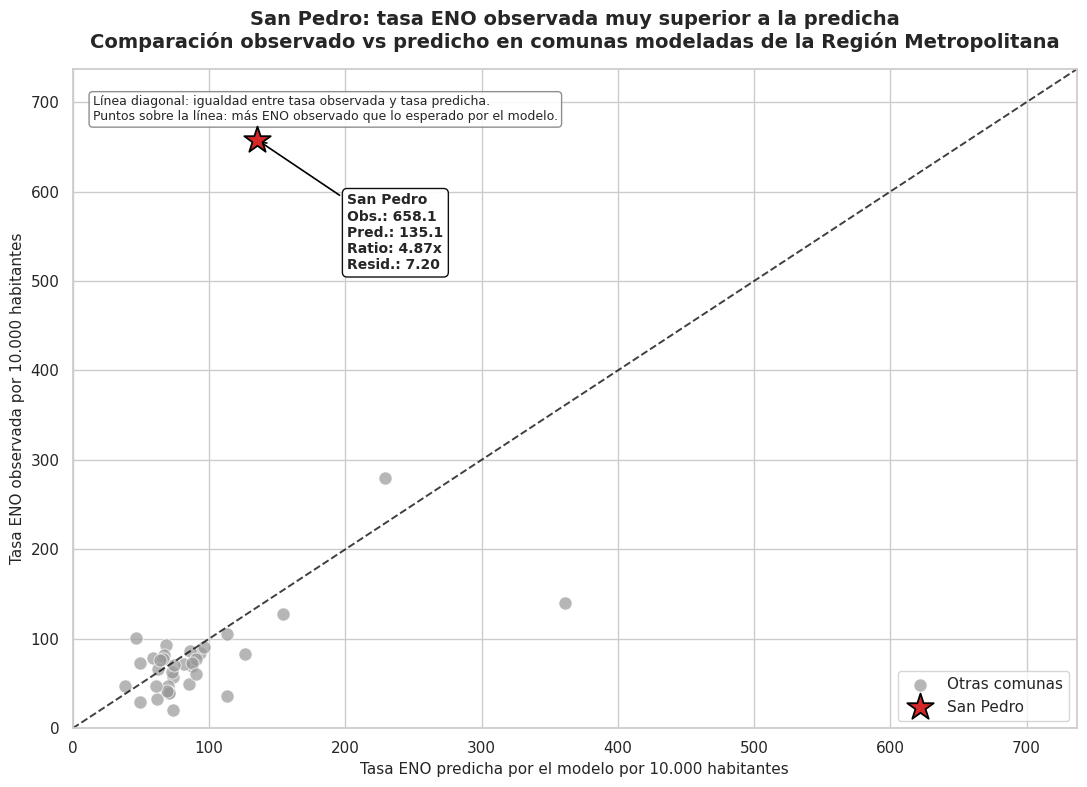

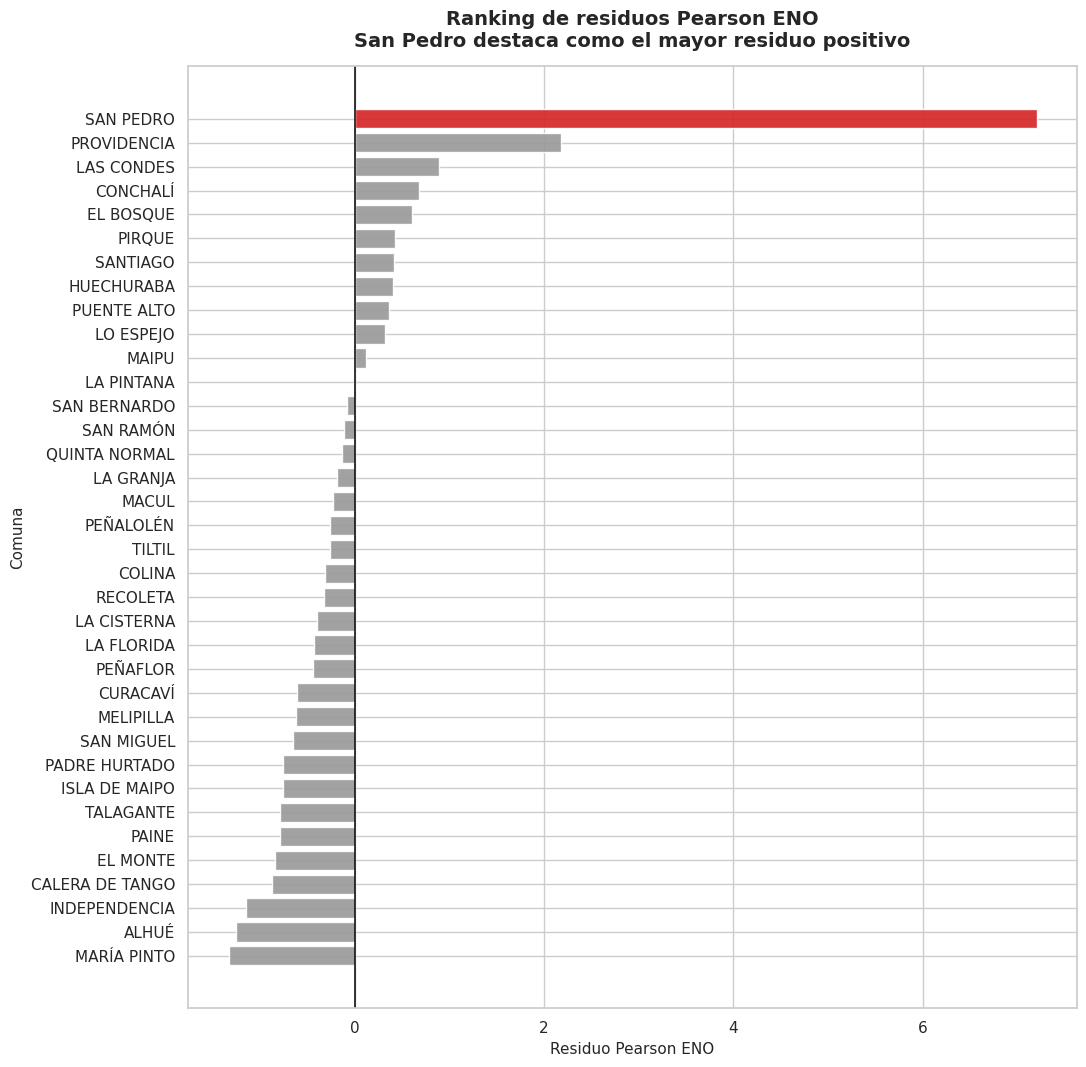

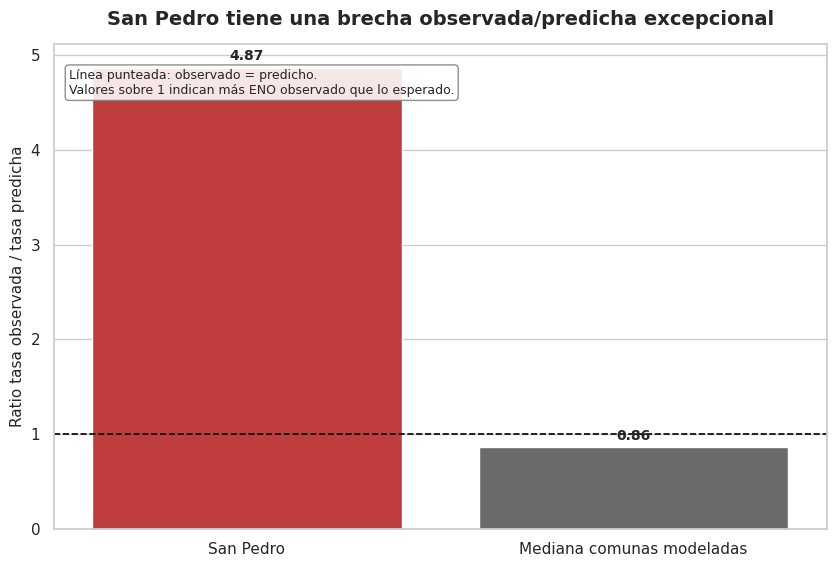

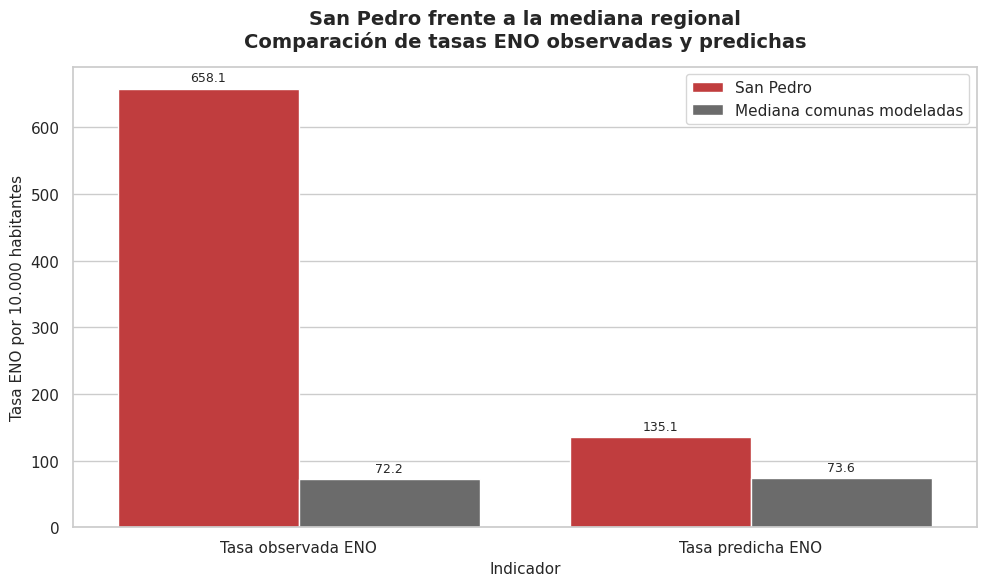

,figura,ruta,uso
0,fig_01_headline_observado_vs_predicho,/content/drive/MyDrive/ColabNotebooks/final_pr...,Figura principal del proyecto
1,fig_02_ranking_residuos_pearson,/content/drive/MyDrive/ColabNotebooks/final_pr...,Evidencia de que San Pedro es el mayor residuo...
2,fig_03_ratio_observada_predicha,/content/drive/MyDrive/ColabNotebooks/final_pr...,Comparación directa del ratio observada/predic...
3,fig_04_tasas_observada_predicha_medianas,/content/drive/MyDrive/ColabNotebooks/final_pr...,Comparación de tasas observadas y predichas co...


Parte 2 ejecutada correctamente.
Índice de figuras Parte 2: /content/drive/MyDrive/ColabNotebooks/final_project_fern/outputs/parte2_indice_figuras.csv


In [3]:
# ============================================================
# PARTE 2: VISUALIZACIONES CENTRALES DE LA ANOMALÍA
# ============================================================

# ------------------------------------------------------------
# 2.1 Base para visualización
# ------------------------------------------------------------

df_viz_fern = df_pred_work_fern.copy()

df_viz_fern["grupo_grafico_fern"] = np.where(
    df_viz_fern["es_san_pedro_fern"],
    "San Pedro",
    "Otras comunas"
)

df_viz_fern["color_grafico_fern"] = np.where(
    df_viz_fern["es_san_pedro_fern"],
    "#d62728",
    "#9a9a9a"
)

max_tasa_fern = np.nanmax([
    df_viz_fern[COL_OBS_RATE_FERN].max(),
    df_viz_fern[COL_PRED_RATE_FERN].max()
])

lim_tasa_fern = max_tasa_fern * 1.12

df_otras_fern = df_viz_fern[~df_viz_fern["es_san_pedro_fern"]].copy()
df_san_pedro_viz_fern = df_viz_fern[df_viz_fern["es_san_pedro_fern"]].copy()

# ------------------------------------------------------------
# 2.2 Figura 1: observado vs predicho
# ------------------------------------------------------------

fig_fern, ax_fern = plt.subplots(figsize=(11, 8))

ax_fern.scatter(
    df_otras_fern[COL_PRED_RATE_FERN],
    df_otras_fern[COL_OBS_RATE_FERN],
    s=90,
    color="#9a9a9a",
    alpha=0.72,
    edgecolor="white",
    linewidth=0.7,
    label="Otras comunas"
)

ax_fern.scatter(
    df_san_pedro_viz_fern[COL_PRED_RATE_FERN],
    df_san_pedro_viz_fern[COL_OBS_RATE_FERN],
    s=400,
    color="#d62728",
    marker="*",
    edgecolor="black",
    linewidth=1.3,
    label="San Pedro",
    zorder=5
)

ax_fern.plot(
    [0, lim_tasa_fern],
    [0, lim_tasa_fern],
    linestyle="--",
    color="black",
    linewidth=1.4,
    alpha=0.75
)

ax_fern.annotate(
    (
        f"San Pedro\n"
        f"Obs.: {obs_rate_sanpedro_fern:.1f}\n"
        f"Pred.: {pred_rate_sanpedro_fern:.1f}\n"
        f"Ratio: {ratio_sanpedro_fern:.2f}x\n"
        f"Resid.: {resid_sanpedro_fern:.2f}"
    ),
    xy=(pred_rate_sanpedro_fern, obs_rate_sanpedro_fern),
    xytext=(pred_rate_sanpedro_fern + lim_tasa_fern * 0.09, obs_rate_sanpedro_fern * 0.78),
    arrowprops=dict(
        arrowstyle="->",
        color="black",
        linewidth=1.2
    ),
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="black",
        alpha=0.94
    ),
    fontsize=10,
    weight="bold"
)

ax_fern.text(
    0.02,
    0.96,
    "Línea diagonal: igualdad entre tasa observada y tasa predicha.\nPuntos sobre la línea: más ENO observado que lo esperado por el modelo.",
    transform=ax_fern.transAxes,
    fontsize=9,
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.30",
        facecolor="white",
        edgecolor="gray",
        alpha=0.88
    )
)

ax_fern.set_xlim(0, lim_tasa_fern)
ax_fern.set_ylim(0, lim_tasa_fern)
ax_fern.set_xlabel("Tasa ENO predicha por el modelo por 10.000 habitantes")
ax_fern.set_ylabel("Tasa ENO observada por 10.000 habitantes")
ax_fern.set_title(
    "San Pedro: tasa ENO observada muy superior a la predicha\n"
    "Comparación observado vs predicho en comunas modeladas de la Región Metropolitana",
    weight="bold",
    pad=15
)
ax_fern.legend(loc="lower right", frameon=True)

plt.tight_layout()

RUTA_FIG_HEADLINE_FERN = RUTA_FINAL_FIGS_FERN / "fig_01_headline_observado_vs_predicho.png"
plt.savefig(RUTA_FIG_HEADLINE_FERN, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 2.3 Figura 2: ranking de residuos Pearson ENO
# ------------------------------------------------------------

df_resid_ranking_plot_fern = df_viz_fern.sort_values(COL_RESID_FERN, ascending=True).copy()

fig_fern, ax_fern = plt.subplots(figsize=(11, max(8, 0.30 * len(df_resid_ranking_plot_fern))))

ax_fern.barh(
    df_resid_ranking_plot_fern["nombre_comuna"],
    df_resid_ranking_plot_fern[COL_RESID_FERN],
    color=df_resid_ranking_plot_fern["color_grafico_fern"],
    alpha=0.92
)

ax_fern.axvline(0, color="black", linewidth=1.1)

ax_fern.set_xlabel("Residuo Pearson ENO")
ax_fern.set_ylabel("Comuna")
ax_fern.set_title(
    "Ranking de residuos Pearson ENO\n"
    "San Pedro destaca como el mayor residuo positivo",
    weight="bold",
    pad=14
)

plt.tight_layout()

RUTA_FIG_RANKING_RESID_FERN = RUTA_FINAL_FIGS_FERN / "fig_02_ranking_residuos_pearson.png"
plt.savefig(RUTA_FIG_RANKING_RESID_FERN, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 2.4 Figura 3: ratio observada/predicha contra referencia regional
# ------------------------------------------------------------

df_ratio_medianas_fern = pd.DataFrame([
    {
        "grupo_fern": "San Pedro",
        "ratio_observada_predicha": ratio_sanpedro_fern
    },
    {
        "grupo_fern": "Mediana comunas modeladas",
        "ratio_observada_predicha": df_resumen_regional_fern.loc[0, "mediana_ratio_observada_predicha"]
    }
])

fig_fern, ax_fern = plt.subplots(figsize=(8.5, 5.8))

sns.barplot(
    data=df_ratio_medianas_fern,
    x="grupo_fern",
    y="ratio_observada_predicha",
    ax=ax_fern,
    palette=["#d62728", "#6b6b6b"]
)

ax_fern.axhline(
    1,
    linestyle="--",
    color="black",
    linewidth=1.2
)

ax_fern.set_xlabel("")
ax_fern.set_ylabel("Ratio tasa observada / tasa predicha")
ax_fern.set_title(
    "San Pedro tiene una brecha observada/predicha excepcional",
    weight="bold",
    pad=14
)

ax_fern.text(
    0.02,
    0.95,
    "Línea punteada: observado = predicho.\nValores sobre 1 indican más ENO observado que lo esperado.",
    transform=ax_fern.transAxes,
    fontsize=9,
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.30",
        facecolor="white",
        edgecolor="gray",
        alpha=0.88
    )
)

for container_fern in ax_fern.containers:
    ax_fern.bar_label(
        container_fern,
        fmt="%.2f",
        padding=3,
        fontsize=10,
        weight="bold"
    )

plt.tight_layout()

RUTA_FIG_RATIO_FERN = RUTA_FINAL_FIGS_FERN / "fig_03_ratio_observada_predicha.png"
plt.savefig(RUTA_FIG_RATIO_FERN, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 2.5 Figura 4: tasas observada y predicha contra medianas
# ------------------------------------------------------------

df_tasas_medianas_fern = pd.DataFrame([
    {
        "indicador": "Tasa observada ENO",
        "San Pedro": obs_rate_sanpedro_fern,
        "Mediana comunas modeladas": df_resumen_regional_fern.loc[0, "mediana_tasa_observada_10k"]
    },
    {
        "indicador": "Tasa predicha ENO",
        "San Pedro": pred_rate_sanpedro_fern,
        "Mediana comunas modeladas": df_resumen_regional_fern.loc[0, "mediana_tasa_predicha_10k"]
    }
])

df_tasas_medianas_largo_fern = df_tasas_medianas_fern.melt(
    id_vars="indicador",
    var_name="grupo_fern",
    value_name="valor_fern"
)

fig_fern, ax_fern = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_tasas_medianas_largo_fern,
    x="indicador",
    y="valor_fern",
    hue="grupo_fern",
    ax=ax_fern,
    palette=["#d62728", "#6b6b6b"]
)

ax_fern.set_xlabel("Indicador")
ax_fern.set_ylabel("Tasa ENO por 10.000 habitantes")
ax_fern.set_title(
    "San Pedro frente a la mediana regional\n"
    "Comparación de tasas ENO observadas y predichas",
    weight="bold",
    pad=14
)

ax_fern.legend(title="")

for container_fern in ax_fern.containers:
    ax_fern.bar_label(
        container_fern,
        fmt="%.1f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()

RUTA_FIG_TASAS_MEDIANAS_FERN = RUTA_FINAL_FIGS_FERN / "fig_04_tasas_observada_predicha_medianas.png"
plt.savefig(RUTA_FIG_TASAS_MEDIANAS_FERN, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 2.6 Índice de figuras principales
# ------------------------------------------------------------

df_figuras_parte2_fern = pd.DataFrame([
    {
        "figura": "fig_01_headline_observado_vs_predicho",
        "ruta": str(RUTA_FIG_HEADLINE_FERN),
        "uso": "Figura principal del proyecto"
    },
    {
        "figura": "fig_02_ranking_residuos_pearson",
        "ruta": str(RUTA_FIG_RANKING_RESID_FERN),
        "uso": "Evidencia de que San Pedro es el mayor residuo positivo ENO"
    },
    {
        "figura": "fig_03_ratio_observada_predicha",
        "ruta": str(RUTA_FIG_RATIO_FERN),
        "uso": "Comparación directa del ratio observada/predicha contra la referencia regional"
    },
    {
        "figura": "fig_04_tasas_observada_predicha_medianas",
        "ruta": str(RUTA_FIG_TASAS_MEDIANAS_FERN),
        "uso": "Comparación de tasas observadas y predichas contra medianas regionales"
    }
])

RUTA_INDICE_FIGURAS_PARTE2_FERN = RUTA_FINAL_OUTPUTS_FERN / "parte2_indice_figuras.csv"
df_figuras_parte2_fern.to_csv(RUTA_INDICE_FIGURAS_PARTE2_FERN, index=False)

display(df_figuras_parte2_fern)

print("Parte 2 ejecutada correctamente.")
print("Índice de figuras Parte 2:", RUTA_INDICE_FIGURAS_PARTE2_FERN)

Análisis de las visualizaciones de la anomalía

Las visualizaciones permiten confirmar que San Pedro no es solo una comuna con una tasa ENO alta, sino una comuna que se comporta de manera excepcional frente a lo que el modelo esperaba. La figura principal compara la tasa ENO observada con la tasa ENO predicha por el modelo. La línea diagonal representa el escenario en que lo observado coincide con lo predicho. En ese gráfico, San Pedro aparece muy por encima de la línea, lo que indica que su tasa observada supera ampliamente la tasa esperada. Mientras el modelo predice aproximadamente 135,1 notificaciones ENO por cada 10.000 habitantes, la comuna registra una tasa observada de 658,1 por cada 10.000 habitantes. Esto equivale a una razón observada/predicha de 4,87 veces, con un residuo Pearson de 7,20.

El ranking de residuos Pearson refuerza la magnitud de la anomalía. San Pedro aparece como el mayor residuo positivo entre las comunas modeladas, claramente separado del resto. La segunda comuna con mayor residuo positivo es Providencia, pero su residuo es mucho menor. Esto muestra que San Pedro no es simplemente una comuna más dentro del grupo de valores altos, sino el caso más extremo del análisis ENO. En términos de defensa del hallazgo, esta figura es clave porque ordena todas las comunas bajo la misma métrica de comparación: cuánto se aleja cada una de lo que el modelo predice.

La comparación entre tasas observadas y predichas para las comunas con mayores residuos positivos también muestra que San Pedro es el caso más llamativo. Otras comunas, como Providencia, Las Condes, Conchalí o El Bosque, presentan tasas observadas superiores a las predichas, pero la brecha es mucho menor. En San Pedro, en cambio, la diferencia visual entre ambas barras es muy amplia. Esto confirma que la anomalía no depende únicamente de que el modelo prediga una tasa baja, sino de que la tasa observada es extraordinariamente alta en comparación con su propia predicción.

La comparación contra la mediana regional entrega una lectura adicional. San Pedro tiene una tasa ENO observada de 658,1 por 10.000 habitantes, mientras que la mediana de las comunas modeladas es aproximadamente 72,2 por 10.000. Es decir, la tasa observada de San Pedro es más de nueve veces la mediana regional modelada. Por otro lado, su tasa predicha también es superior a la mediana: 135,1 frente a 73,6. Esto es importante porque indica que el modelo sí esperaba que San Pedro tuviera una tasa ENO relativamente alta, pero la tasa real fue mucho mayor que esa expectativa.

La figura del ratio observada/predicha resume de forma directa la anomalía central. La mediana de las comunas modeladas tiene un ratio cercano a 0,86, es decir, en una comuna típica lo observado está cerca de lo predicho o incluso algo por debajo. San Pedro, en cambio, tiene un ratio de 4,87, muy por encima de la línea de igualdad. Esto significa que su tasa observada fue casi cinco veces la tasa esperada por el modelo. Esta es probablemente la visualización más clara para explicar la anomalía en una presentación o video.

En conjunto, los gráficos permiten defender que San Pedro es una anomalía ENO real dentro del análisis comunal. La comuna lidera simultáneamente el ranking de tasa observada, ratio observada/predicha y residuo Pearson. Además, el modelo ya incorporaba población y covariables comunales, por lo que la señal no se reduce simplemente a comparar conteos brutos. La interpretación correcta es que San Pedro presenta una carga de notificaciones ENO mucho mayor que la esperada para su perfil comunal, lo que justifica analizar explicaciones alternativas como población pequeña, ruralidad, vigilancia sanitaria local, diferencias de registro, brotes específicos o exposición territorial.

,check,pop_san_pedro,percentil_poblacion_san_pedro,corr_pop_total_abs_resid,corr_inv_pop_abs_resid,corr_log_pop_abs_resid,residuo_pearson_san_pedro,ratio_observada_predicha_san_pedro
0,poblacion_pequena,11108.0,5.555556,-0.285248,0.575407,-0.492951,7.200426,4.870065


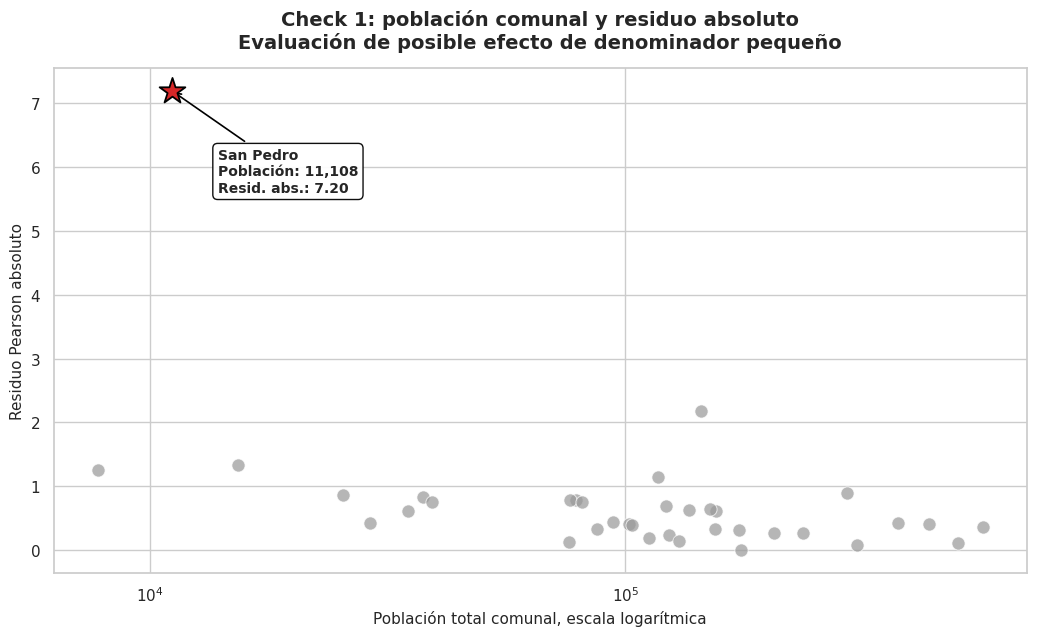

,codigo_comuna,nombre_comuna,pop_total,obs_rate_eno_per_10k,pred_rate_eno_per_10k,ratio_obs_pred_fern,pearson_resid_eno,abs_resid_fern,grupo_territorial_fern
30,13505,SAN PEDRO,11108.0,658.084264,135.128432,4.870065,7.200426,7.200426,Provincias periféricas RM
21,13202,PIRQUE,29060.0,46.799725,38.046869,1.230055,0.426273,0.426273,Provincias periféricas RM
19,13131,SAN RAMÓN,76002.0,90.392358,96.423233,0.937454,-0.117451,0.117451,Provincia de Santiago
28,13503,CURACAVÍ,34977.0,47.173857,69.938728,0.674503,-0.608319,0.608319,Provincias periféricas RM
33,13603,ISLA DE MAIPO,39274.0,29.281458,49.206000,0.595079,-0.755321,0.755321,Provincias periféricas RM
32,13602,EL MONTE,37497.0,38.936448,70.544267,0.551943,-0.837818,0.837818,Provincias periféricas RM
24,13403,CALERA DE TANGO,25491.0,32.952807,61.824593,0.533005,-0.869342,0.869342,Provincias periféricas RM
27,13502,ALHUÉ,7768.0,36.045314,113.101010,0.318700,-1.257358,1.257358,Provincias periféricas RM
29,13504,MARÍA PINTO,15352.0,20.844190,73.876628,0.282149,-1.330640,1.330640,Provincias periféricas RM


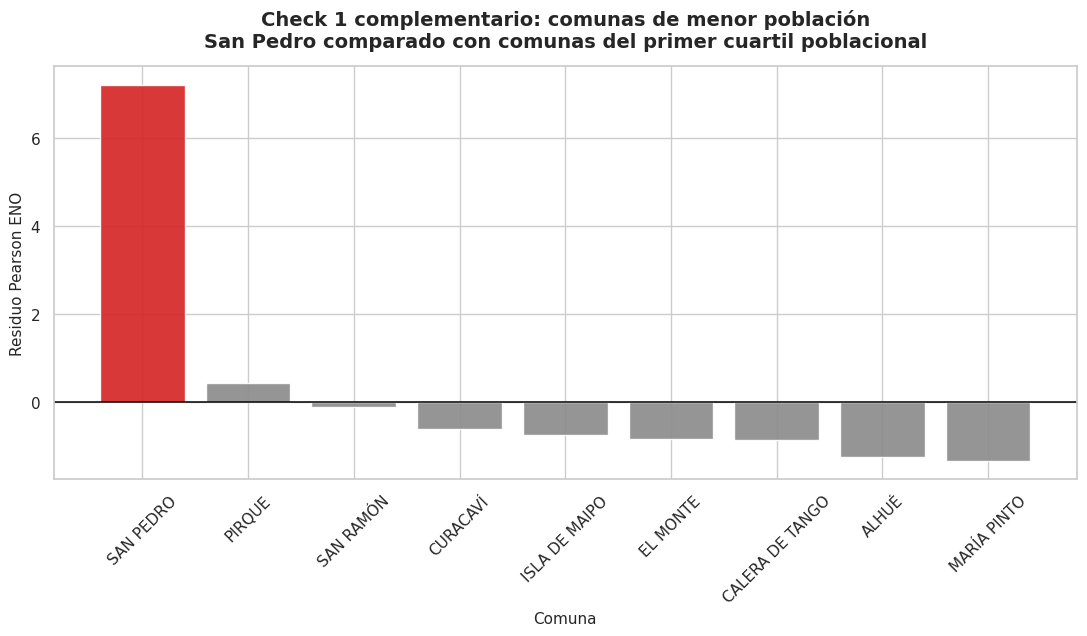

,variable,san_pedro,min_rm,p25_rm,mediana_rm,media_rm,p75_rm,max_rm,percentil_san_pedro
0,pct_foreign,11.343176,0.000000,4.579603,8.124115,10.323616,11.760843,44.387437,73.809524
1,mean_schooling_total,9.726387,9.726387,11.068132,12.016855,12.145742,12.771435,16.460279,2.564103
2,pct_unemployed,37.841510,22.643431,34.468109,37.841510,39.840273,39.597697,99.369344,51.282051
3,dependency_ratio,56.826204,0.434953,38.568868,45.550000,38.532110,47.505130,56.826204,100.000000


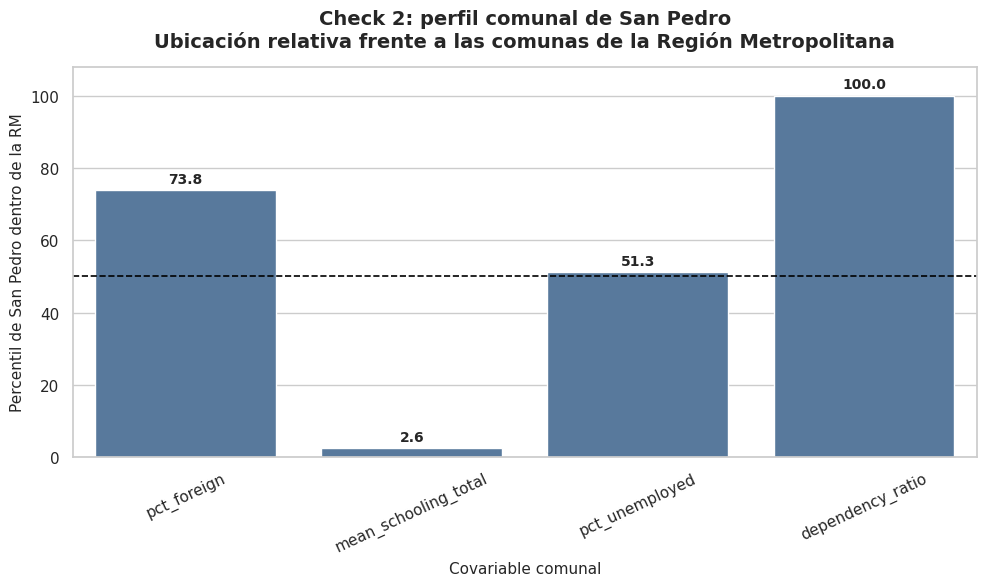

,variable_grd,san_pedro,min_rm,p25_rm,mediana_rm,media_rm,p75_rm,max_rm,percentil_san_pedro
0,grd_rate_per_10k,1219.841556,69.787573,693.655442,1096.695344,1004.558346,1287.922864,1630.640445,62.500
1,grd_total,1355.000000,900.000000,4944.000000,10783.000000,15882.140625,15425.000000,62614.000000,6.250
2,grd_mean_los,4.900369,4.780000,5.557737,6.006449,7.321313,6.394472,23.594800,9.375


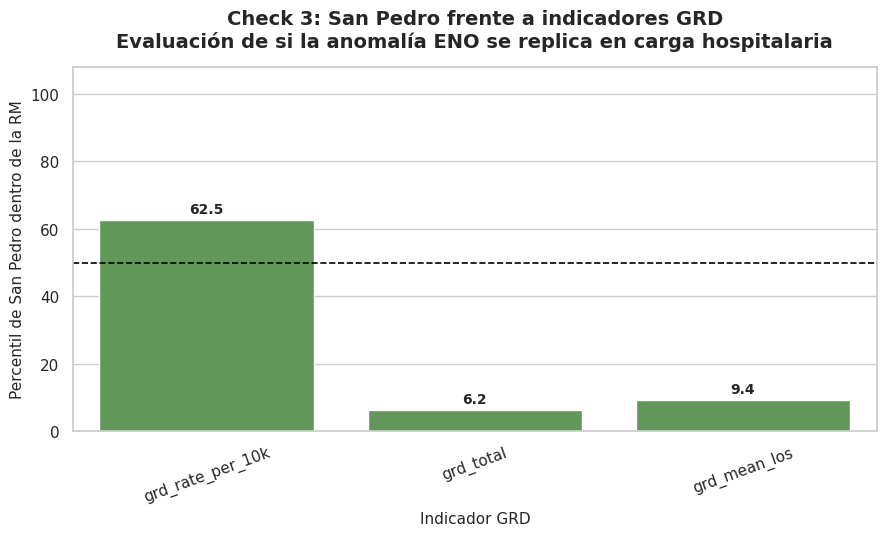

,grupo_territorial_fern,n_comunas,mediana_tasa_obs,media_tasa_obs,mediana_tasa_pred,media_tasa_pred,mediana_ratio,media_ratio,mediana_residuo,media_residuo
0,Provincia de Santiago,20,82.265733,95.273065,84.074310,104.307284,0.933115,1.039393,-0.125681,0.073774
1,Provincias periféricas RM,16,46.757418,85.602572,70.694988,75.896658,0.633742,0.951886,-0.687805,-0.091158


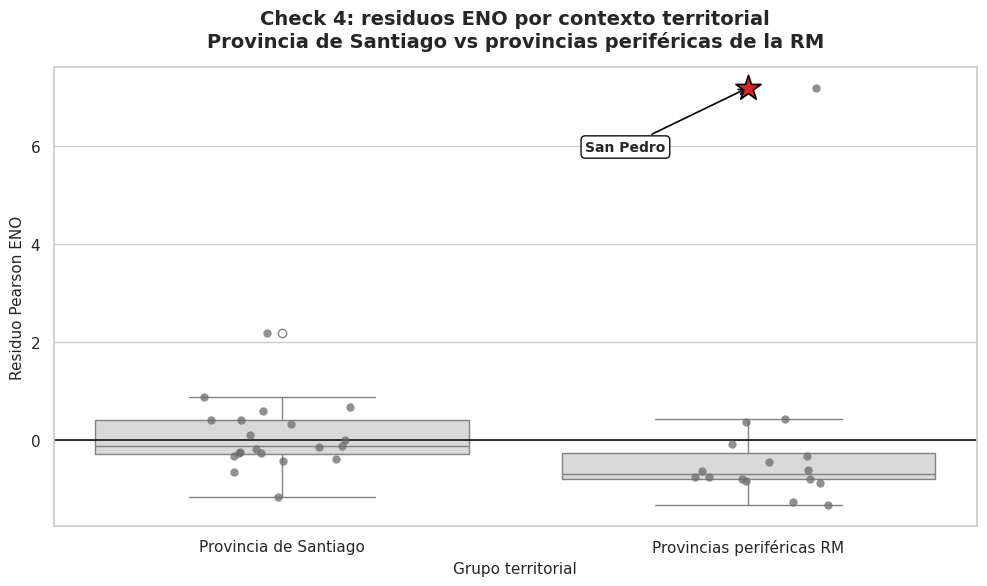

,figura,ruta,uso
0,fig_05_check_poblacion_residuo,/content/drive/MyDrive/ColabNotebooks/final_pr...,Evalúa si San Pedro es extremo solo por poblac...
1,fig_06_check_comunas_baja_poblacion,/content/drive/MyDrive/ColabNotebooks/final_pr...,Compara San Pedro con comunas de baja población
2,fig_07_check_perfil_demografico,/content/drive/MyDrive/ColabNotebooks/final_pr...,Describe el perfil comunal no promedio de San ...
3,fig_08_check_grd,/content/drive/MyDrive/ColabNotebooks/final_pr...,Evalúa si la anomalía ENO se replica en indica...
4,fig_09_check_contexto_territorial,/content/drive/MyDrive/ColabNotebooks/final_pr...,Compara San Pedro contra contextos territorial...


Parte 3 ejecutada correctamente.
Check población: /content/drive/MyDrive/ColabNotebooks/final_project_fern/outputs/parte3_check_poblacion.csv
Check baja población: /content/drive/MyDrive/ColabNotebooks/final_project_fern/outputs/parte3_comunas_baja_poblacion.csv
Check perfil demográfico: /content/drive/MyDrive/ColabNotebooks/final_project_fern/outputs/parte3_check_perfil_demografico.csv
Check GRD: /content/drive/MyDrive/ColabNotebooks/final_project_fern/outputs/parte3_check_grd.csv
Check contexto territorial: /content/drive/MyDrive/ColabNotebooks/final_project_fern/outputs/parte3_check_contexto_territorial.csv
Índice de figuras Parte 3: /content/drive/MyDrive/ColabNotebooks/final_project_fern/outputs/parte3_indice_figuras.csv


In [4]:
# ============================================================
# PARTE 3: CHECKS ALTERNATIVOS DE LA ANOMALÍA
# ============================================================

# ------------------------------------------------------------
# 3.1 Preparación de bases auxiliares
# ------------------------------------------------------------

df_checks_fern = df_pred_work_fern.copy()

df_checks_fern["codigo_comuna"] = pd.to_numeric(
    df_checks_fern["codigo_comuna"],
    errors="coerce"
).astype(int)

df_checks_fern["nombre_comuna"] = (
    df_checks_fern["nombre_comuna"]
    .astype(str)
    .str.strip()
    .str.upper()
)

for columna_fern in [
    "pop_total",
    COL_OBS_RATE_FERN,
    COL_PRED_RATE_FERN,
    COL_RESID_FERN,
    "ratio_obs_pred_fern"
]:
    df_checks_fern[columna_fern] = pd.to_numeric(
        df_checks_fern[columna_fern],
        errors="coerce"
    )

df_checks_fern["abs_resid_fern"] = df_checks_fern[COL_RESID_FERN].abs()
df_checks_fern["inv_pop_fern"] = 1 / df_checks_fern["pop_total"].replace(0, np.nan)
df_checks_fern["log_pop_total_fern"] = np.log(df_checks_fern["pop_total"].replace(0, np.nan))

df_checks_fern["es_san_pedro_fern"] = df_checks_fern["codigo_comuna"].eq(CODIGO_ANOMALIA_FERN)

df_checks_fern["grupo_territorial_fern"] = np.where(
    df_checks_fern["codigo_comuna"].between(13101, 13132),
    "Provincia de Santiago",
    "Provincias periféricas RM"
)

df_checks_validos_fern = df_checks_fern.dropna(
    subset=[
        "pop_total",
        "abs_resid_fern",
        "inv_pop_fern",
        "log_pop_total_fern",
        COL_OBS_RATE_FERN,
        COL_PRED_RATE_FERN,
        COL_RESID_FERN,
        "ratio_obs_pred_fern"
    ]
).copy()

df_san_pedro_check_fern = df_checks_validos_fern[
    df_checks_validos_fern["es_san_pedro_fern"]
].copy()

if len(df_san_pedro_check_fern) != 1:
    raise ValueError("San Pedro debe aparecer exactamente una vez en la base de checks.")

fila_san_pedro_check_fern = df_san_pedro_check_fern.iloc[0]

# ------------------------------------------------------------
# 3.2 Check 1: población pequeña y volatilidad de tasas
# ------------------------------------------------------------

percentil_pop_san_pedro_fern = stats.percentileofscore(
    df_checks_validos_fern["pop_total"],
    pop_sanpedro_fern
)

corr_pop_abs_resid_fern = df_checks_validos_fern[
    ["pop_total", "abs_resid_fern"]
].corr().iloc[0, 1]

corr_invpop_abs_resid_fern = df_checks_validos_fern[
    ["inv_pop_fern", "abs_resid_fern"]
].corr().iloc[0, 1]

corr_logpop_abs_resid_fern = df_checks_validos_fern[
    ["log_pop_total_fern", "abs_resid_fern"]
].corr().iloc[0, 1]

df_check_poblacion_fern = pd.DataFrame([{
    "check": "poblacion_pequena",
    "pop_san_pedro": pop_sanpedro_fern,
    "percentil_poblacion_san_pedro": percentil_pop_san_pedro_fern,
    "corr_pop_total_abs_resid": corr_pop_abs_resid_fern,
    "corr_inv_pop_abs_resid": corr_invpop_abs_resid_fern,
    "corr_log_pop_abs_resid": corr_logpop_abs_resid_fern,
    "residuo_pearson_san_pedro": resid_sanpedro_fern,
    "ratio_observada_predicha_san_pedro": ratio_sanpedro_fern
}])

display(df_check_poblacion_fern)

fig_fern, ax_fern = plt.subplots(figsize=(10.5, 6.5))

df_no_san_pedro_pop_fern = df_checks_validos_fern[
    ~df_checks_validos_fern["es_san_pedro_fern"]
].copy()

ax_fern.scatter(
    df_no_san_pedro_pop_fern["pop_total"],
    df_no_san_pedro_pop_fern["abs_resid_fern"],
    s=90,
    color="#9a9a9a",
    alpha=0.72,
    edgecolor="white",
    linewidth=0.7
)

ax_fern.scatter(
    [pop_sanpedro_fern],
    [abs(resid_sanpedro_fern)],
    s=380,
    color="#d62728",
    marker="*",
    edgecolor="black",
    linewidth=1.3,
    zorder=5
)

ax_fern.annotate(
    (
        f"San Pedro\n"
        f"Población: {pop_sanpedro_fern:,.0f}\n"
        f"Resid. abs.: {abs(resid_sanpedro_fern):.2f}"
    ),
    xy=(pop_sanpedro_fern, abs(resid_sanpedro_fern)),
    xytext=(pop_sanpedro_fern * 1.25, abs(resid_sanpedro_fern) * 0.78),
    arrowprops=dict(
        arrowstyle="->",
        color="black",
        linewidth=1.2
    ),
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="black",
        alpha=0.94
    ),
    fontsize=10,
    weight="bold"
)

ax_fern.set_xscale("log")
ax_fern.set_xlabel("Población total comunal, escala logarítmica")
ax_fern.set_ylabel("Residuo Pearson absoluto")
ax_fern.set_title(
    "Check 1: población comunal y residuo absoluto\n"
    "Evaluación de posible efecto de denominador pequeño",
    weight="bold",
    pad=14
)

plt.tight_layout()

RUTA_FIG_CHECK1_FERN = RUTA_FINAL_FIGS_FERN / "fig_05_check_poblacion_residuo.png"
plt.savefig(RUTA_FIG_CHECK1_FERN, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 3.3 Check 1 complementario: comunas de menor población
# ------------------------------------------------------------

umbral_primer_cuartil_pop_fern = df_checks_validos_fern["pop_total"].quantile(0.25)

df_comunas_baja_poblacion_fern = (
    df_checks_validos_fern[
        df_checks_validos_fern["pop_total"] <= umbral_primer_cuartil_pop_fern
    ]
    [
        [
            "codigo_comuna",
            "nombre_comuna",
            "pop_total",
            COL_OBS_RATE_FERN,
            COL_PRED_RATE_FERN,
            "ratio_obs_pred_fern",
            COL_RESID_FERN,
            "abs_resid_fern",
            "grupo_territorial_fern"
        ]
    ]
    .sort_values(COL_RESID_FERN, ascending=False)
    .copy()
)

display(df_comunas_baja_poblacion_fern)

fig_fern, ax_fern = plt.subplots(figsize=(11, 6.5))

df_baja_pop_plot_fern = df_comunas_baja_poblacion_fern.copy()

df_baja_pop_plot_fern["color_fern"] = np.where(
    df_baja_pop_plot_fern["codigo_comuna"].eq(CODIGO_ANOMALIA_FERN),
    "#d62728",
    "#8c8c8c"
)

ax_fern.bar(
    df_baja_pop_plot_fern["nombre_comuna"],
    df_baja_pop_plot_fern[COL_RESID_FERN],
    color=df_baja_pop_plot_fern["color_fern"],
    alpha=0.92
)

ax_fern.axhline(0, color="black", linewidth=1.1)

ax_fern.set_xlabel("Comuna")
ax_fern.set_ylabel("Residuo Pearson ENO")
ax_fern.set_title(
    "Check 1 complementario: comunas de menor población\n"
    "San Pedro comparado con comunas del primer cuartil poblacional",
    weight="bold",
    pad=14
)

ax_fern.tick_params(axis="x", rotation=45)

plt.tight_layout()

RUTA_FIG_CHECK1_BAJA_POP_FERN = RUTA_FINAL_FIGS_FERN / "fig_06_check_comunas_baja_poblacion.png"
plt.savefig(RUTA_FIG_CHECK1_BAJA_POP_FERN, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 3.4 Check 2: perfil demográfico de San Pedro
# ------------------------------------------------------------

df_contexto_fern = df_analitica_fern.copy()
df_contexto_fern = preparar_codigo_comuna_fern(df_contexto_fern)

covariables_contexto_fern = [
    "pct_foreign",
    "mean_schooling_total",
    "pct_unemployed",
    "dependency_ratio"
]

covariables_contexto_fern = [
    columna_fern
    for columna_fern in covariables_contexto_fern
    if columna_fern in df_contexto_fern.columns
]

for columna_fern in covariables_contexto_fern:
    df_contexto_fern[columna_fern] = pd.to_numeric(
        df_contexto_fern[columna_fern],
        errors="coerce"
    )

df_contexto_san_pedro_fern = df_contexto_fern[
    df_contexto_fern["codigo_comuna"].eq(CODIGO_ANOMALIA_FERN)
].copy()

if len(df_contexto_san_pedro_fern) != 1:
    raise ValueError("San Pedro debe aparecer exactamente una vez en la tabla analítica.")

fila_contexto_san_pedro_fern = df_contexto_san_pedro_fern.iloc[0]

registros_perfil_fern = []

for columna_fern in covariables_contexto_fern:
    serie_fern = df_contexto_fern[columna_fern].dropna()
    valor_fern = fila_contexto_san_pedro_fern[columna_fern]

    if len(serie_fern) > 0 and pd.notna(valor_fern):
        registros_perfil_fern.append({
            "variable": columna_fern,
            "san_pedro": valor_fern,
            "min_rm": serie_fern.min(),
            "p25_rm": serie_fern.quantile(0.25),
            "mediana_rm": serie_fern.median(),
            "media_rm": serie_fern.mean(),
            "p75_rm": serie_fern.quantile(0.75),
            "max_rm": serie_fern.max(),
            "percentil_san_pedro": stats.percentileofscore(serie_fern, valor_fern)
        })

df_check_perfil_fern = pd.DataFrame(registros_perfil_fern)

display(df_check_perfil_fern)

fig_fern, ax_fern = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_check_perfil_fern,
    x="variable",
    y="percentil_san_pedro",
    color="#4c78a8",
    ax=ax_fern
)

ax_fern.axhline(
    50,
    linestyle="--",
    color="black",
    linewidth=1.2
)

for container_fern in ax_fern.containers:
    ax_fern.bar_label(
        container_fern,
        fmt="%.1f",
        padding=3,
        fontsize=10,
        weight="bold"
    )

ax_fern.set_ylim(0, 108)
ax_fern.set_xlabel("Covariable comunal")
ax_fern.set_ylabel("Percentil de San Pedro dentro de la RM")
ax_fern.set_title(
    "Check 2: perfil comunal de San Pedro\n"
    "Ubicación relativa frente a las comunas de la Región Metropolitana",
    weight="bold",
    pad=14
)

ax_fern.tick_params(axis="x", rotation=25)

plt.tight_layout()

RUTA_FIG_CHECK2_PERFIL_FERN = RUTA_FINAL_FIGS_FERN / "fig_07_check_perfil_demografico.png"
plt.savefig(RUTA_FIG_CHECK2_PERFIL_FERN, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 3.5 Check 3: comparación con indicadores GRD
# ------------------------------------------------------------

variables_grd_check_fern = [
    "grd_rate_per_10k",
    "grd_total",
    "grd_mean_los"
]

variables_grd_check_fern = [
    columna_fern
    for columna_fern in variables_grd_check_fern
    if columna_fern in df_contexto_fern.columns
]

for columna_fern in variables_grd_check_fern:
    df_contexto_fern[columna_fern] = pd.to_numeric(
        df_contexto_fern[columna_fern],
        errors="coerce"
    )

df_contexto_san_pedro_fern = df_contexto_fern[
    df_contexto_fern["codigo_comuna"].eq(CODIGO_ANOMALIA_FERN)
].copy()

fila_contexto_san_pedro_fern = df_contexto_san_pedro_fern.iloc[0]

registros_grd_fern = []

for columna_fern in variables_grd_check_fern:
    serie_fern = df_contexto_fern[columna_fern].dropna()
    valor_fern = fila_contexto_san_pedro_fern[columna_fern]

    if len(serie_fern) > 0 and pd.notna(valor_fern):
        registros_grd_fern.append({
            "variable_grd": columna_fern,
            "san_pedro": valor_fern,
            "min_rm": serie_fern.min(),
            "p25_rm": serie_fern.quantile(0.25),
            "mediana_rm": serie_fern.median(),
            "media_rm": serie_fern.mean(),
            "p75_rm": serie_fern.quantile(0.75),
            "max_rm": serie_fern.max(),
            "percentil_san_pedro": stats.percentileofscore(serie_fern, valor_fern)
        })

df_check_grd_fern = pd.DataFrame(registros_grd_fern)

display(df_check_grd_fern)

if len(df_check_grd_fern) > 0:
    fig_fern, ax_fern = plt.subplots(figsize=(9, 5.5))

    sns.barplot(
        data=df_check_grd_fern,
        x="variable_grd",
        y="percentil_san_pedro",
        color="#59a14f",
        ax=ax_fern
    )

    ax_fern.axhline(
        50,
        linestyle="--",
        color="black",
        linewidth=1.2
    )

    for container_fern in ax_fern.containers:
        ax_fern.bar_label(
            container_fern,
            fmt="%.1f",
            padding=3,
            fontsize=10,
            weight="bold"
        )

    ax_fern.set_ylim(0, 108)
    ax_fern.set_xlabel("Indicador GRD")
    ax_fern.set_ylabel("Percentil de San Pedro dentro de la RM")
    ax_fern.set_title(
        "Check 3: San Pedro frente a indicadores GRD\n"
        "Evaluación de si la anomalía ENO se replica en carga hospitalaria",
        weight="bold",
        pad=14
    )

    ax_fern.tick_params(axis="x", rotation=20)

    plt.tight_layout()

    RUTA_FIG_CHECK3_GRD_FERN = RUTA_FINAL_FIGS_FERN / "fig_08_check_grd.png"
    plt.savefig(RUTA_FIG_CHECK3_GRD_FERN, dpi=300, bbox_inches="tight")
    plt.show()

else:
    RUTA_FIG_CHECK3_GRD_FERN = None

# ------------------------------------------------------------
# 3.6 Check 4: contexto territorial
# ------------------------------------------------------------

df_territorio_fern = (
    df_checks_validos_fern
    .groupby("grupo_territorial_fern", as_index=False)
    .agg(
        n_comunas=("codigo_comuna", "nunique"),
        mediana_tasa_obs=(COL_OBS_RATE_FERN, "median"),
        media_tasa_obs=(COL_OBS_RATE_FERN, "mean"),
        mediana_tasa_pred=(COL_PRED_RATE_FERN, "median"),
        media_tasa_pred=(COL_PRED_RATE_FERN, "mean"),
        mediana_ratio=("ratio_obs_pred_fern", "median"),
        media_ratio=("ratio_obs_pred_fern", "mean"),
        mediana_residuo=(COL_RESID_FERN, "median"),
        media_residuo=(COL_RESID_FERN, "mean")
    )
)

display(df_territorio_fern)

fig_fern, ax_fern = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_checks_validos_fern,
    x="grupo_territorial_fern",
    y=COL_RESID_FERN,
    color="#d9d9d9",
    ax=ax_fern
)

sns.stripplot(
    data=df_checks_validos_fern,
    x="grupo_territorial_fern",
    y=COL_RESID_FERN,
    color="#6b6b6b",
    alpha=0.75,
    size=6,
    jitter=0.18,
    ax=ax_fern
)

ax_fern.scatter(
    ["Provincias periféricas RM"],
    [resid_sanpedro_fern],
    s=360,
    color="#d62728",
    marker="*",
    edgecolor="black",
    linewidth=1.2,
    zorder=6
)

ax_fern.annotate(
    "San Pedro",
    xy=("Provincias periféricas RM", resid_sanpedro_fern),
    xytext=(0.65, resid_sanpedro_fern * 0.82),
    textcoords="data",
    arrowprops=dict(
        arrowstyle="->",
        color="black",
        linewidth=1.2
    ),
    bbox=dict(
        boxstyle="round,pad=0.30",
        facecolor="white",
        edgecolor="black",
        alpha=0.94
    ),
    fontsize=10,
    weight="bold"
)

ax_fern.axhline(0, color="black", linewidth=1.1)
ax_fern.set_xlabel("Grupo territorial")
ax_fern.set_ylabel("Residuo Pearson ENO")
ax_fern.set_title(
    "Check 4: residuos ENO por contexto territorial\n"
    "Provincia de Santiago vs provincias periféricas de la RM",
    weight="bold",
    pad=14
)

plt.tight_layout()

RUTA_FIG_CHECK4_TERRITORIO_FERN = RUTA_FINAL_FIGS_FERN / "fig_09_check_contexto_territorial.png"
plt.savefig(RUTA_FIG_CHECK4_TERRITORIO_FERN, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 3.7 Exportación de resultados de Parte 3
# ------------------------------------------------------------

RUTA_CHECK_POBLACION_FERN = RUTA_FINAL_OUTPUTS_FERN / "parte3_check_poblacion.csv"
RUTA_CHECK_BAJA_POBLACION_FERN = RUTA_FINAL_OUTPUTS_FERN / "parte3_comunas_baja_poblacion.csv"
RUTA_CHECK_PERFIL_FERN = RUTA_FINAL_OUTPUTS_FERN / "parte3_check_perfil_demografico.csv"
RUTA_CHECK_GRD_FERN = RUTA_FINAL_OUTPUTS_FERN / "parte3_check_grd.csv"
RUTA_CHECK_TERRITORIO_FERN = RUTA_FINAL_OUTPUTS_FERN / "parte3_check_contexto_territorial.csv"

df_check_poblacion_fern.to_csv(RUTA_CHECK_POBLACION_FERN, index=False)
df_comunas_baja_poblacion_fern.to_csv(RUTA_CHECK_BAJA_POBLACION_FERN, index=False)
df_check_perfil_fern.to_csv(RUTA_CHECK_PERFIL_FERN, index=False)
df_check_grd_fern.to_csv(RUTA_CHECK_GRD_FERN, index=False)
df_territorio_fern.to_csv(RUTA_CHECK_TERRITORIO_FERN, index=False)

df_figuras_parte3_fern = pd.DataFrame([
    {
        "figura": "fig_05_check_poblacion_residuo",
        "ruta": str(RUTA_FIG_CHECK1_FERN),
        "uso": "Evalúa si San Pedro es extremo solo por población pequeña"
    },
    {
        "figura": "fig_06_check_comunas_baja_poblacion",
        "ruta": str(RUTA_FIG_CHECK1_BAJA_POP_FERN),
        "uso": "Compara San Pedro con comunas de baja población"
    },
    {
        "figura": "fig_07_check_perfil_demografico",
        "ruta": str(RUTA_FIG_CHECK2_PERFIL_FERN),
        "uso": "Describe el perfil comunal no promedio de San Pedro"
    },
    {
        "figura": "fig_08_check_grd",
        "ruta": str(RUTA_FIG_CHECK3_GRD_FERN),
        "uso": "Evalúa si la anomalía ENO se replica en indicadores GRD"
    },
    {
        "figura": "fig_09_check_contexto_territorial",
        "ruta": str(RUTA_FIG_CHECK4_TERRITORIO_FERN),
        "uso": "Compara San Pedro contra contextos territoriales de la RM"
    }
])

RUTA_INDICE_FIGURAS_PARTE3_FERN = RUTA_FINAL_OUTPUTS_FERN / "parte3_indice_figuras.csv"
df_figuras_parte3_fern.to_csv(RUTA_INDICE_FIGURAS_PARTE3_FERN, index=False)

display(df_figuras_parte3_fern)

print("Parte 3 ejecutada correctamente.")
print("Check población:", RUTA_CHECK_POBLACION_FERN)
print("Check baja población:", RUTA_CHECK_BAJA_POBLACION_FERN)
print("Check perfil demográfico:", RUTA_CHECK_PERFIL_FERN)
print("Check GRD:", RUTA_CHECK_GRD_FERN)
print("Check contexto territorial:", RUTA_CHECK_TERRITORIO_FERN)
print("Índice de figuras Parte 3:", RUTA_INDICE_FIGURAS_PARTE3_FERN)

Análisis de los checks alternativos de la anomalía

Los checks alternativos permiten evaluar si la anomalía de San Pedro se mantiene después de revisar posibles explicaciones rivales. El objetivo no es probar causalidad, sino determinar si el resultado sigue siendo defendible cuando se consideran factores como población pequeña, perfil demográfico, carga hospitalaria y contexto territorial.

En el Check 1, se analiza si la anomalía podría deberse solamente a que San Pedro tiene una población baja. La comuna tiene 11.108 habitantes y se ubica en el percentil 5,6 de población entre las comunas modeladas, por lo que es razonable pensar que el denominador pequeño puede aumentar la volatilidad de las tasas. Además, la correlación entre población inversa y residuo absoluto es 0,575, lo que indica una relación moderada entre comunas pequeñas y residuos más altos. Sin embargo, al comparar San Pedro con otras comunas del primer cuartil poblacional, la comuna sigue siendo claramente el caso más extremo. Comunas también pequeñas como Pirque, Alhué, María Pinto, Calera de Tango o Isla de Maipo no presentan un residuo positivo comparable. Por lo tanto, la baja población puede ser una explicación parcial, pero no suficiente para explicar la magnitud del residuo de San Pedro.

En el Check 2, se revisa el perfil comunal de San Pedro frente a las demás comunas de la Región Metropolitana. La comuna presenta un porcentaje de población extranjera en el percentil 73,8, una escolaridad promedio muy baja en el percentil 2,6, desempleo cercano a la mediana en el percentil 51,3 y la razón de dependencia más alta de la muestra, en el percentil 100,0. Esto muestra que San Pedro no es una comuna promedio: tiene un perfil territorial particular, especialmente por su alta dependencia demográfica y baja escolaridad promedio. Sin embargo, el modelo ya incorpora parte de estas características y, aun así, predice una tasa de 135,1 ENO por 10.000 habitantes, muy inferior a la tasa observada de 658,1. Por lo tanto, el perfil demográfico ayuda a entender por qué el modelo esperaba una tasa superior a la mediana, pero no explica completamente el exceso observado.

En el Check 3, se compara la anomalía ENO con indicadores GRD para evaluar si San Pedro también aparece como un territorio con carga hospitalaria general extrema. Los resultados muestran que San Pedro está en el percentil 62,5 en tasa GRD por 10.000 habitantes, pero solo en el percentil 6,3 en conteo total GRD y en el percentil 9,4 en duración promedio de estadía hospitalaria. Esto indica que San Pedro no destaca como una anomalía hospitalaria general. Su señal es mucho más fuerte en ENO que en GRD. En consecuencia, la anomalía parece estar más asociada a notificaciones epidemiológicas obligatorias que a una carga hospitalaria global especialmente elevada.

En el Check 4, se compara el comportamiento de San Pedro dentro del contexto territorial de la Región Metropolitana. El gráfico separa comunas de la Provincia de Santiago y comunas de provincias periféricas. San Pedro pertenece al segundo grupo, pero aparece como un punto extremadamente superior incluso dentro de las comunas periféricas. Esto es importante porque descarta una explicación simple basada en que “todas las comunas periféricas se comportan igual”. De hecho, las provincias periféricas presentan una mediana de residuo ENO negativa, cercana a -0,688, mientras que San Pedro tiene un residuo positivo de 7,20. Por lo tanto, San Pedro no solo es extremo frente al conjunto de la Región Metropolitana, sino también frente a comunas territorialmente más comparables.

En conjunto, los checks fortalecen la defensa de la anomalía. San Pedro sigue siendo un caso excepcional aun después de revisar población pequeña, perfil demográfico, indicadores GRD y contexto territorial. La interpretación más prudente es que la baja población y el perfil comunal pueden contribuir al fenómeno, pero no lo explican por completo. La anomalía parece más específica de las notificaciones ENO que de la carga hospitalaria general, lo que sugiere la necesidad de revisar factores adicionales como brotes específicos, vigilancia sanitaria local, diferencias de registro, exposición ambiental o dinámicas propias de una comuna periférica/rural de la Provincia de Melipilla.

In [5]:
# ============================================================
# PARTE 4: CONSOLIDACIÓN FINAL DE EVIDENCIA CUANTITATIVA
# ============================================================

# ------------------------------------------------------------
# 4.1 Funciones auxiliares
# ------------------------------------------------------------

def extraer_percentil_fern(df_fern, columna_id_fern, valor_id_fern, columna_valor_fern="percentil_san_pedro"):
    filtro_fern = df_fern[columna_id_fern].eq(valor_id_fern)

    if filtro_fern.sum() == 0:
        return np.nan

    return float(df_fern.loc[filtro_fern, columna_valor_fern].iloc[0])


def agregar_figura_si_existe_fern(lista_fern, nombre_archivo_fern, etiqueta_fern, rol_fern):
    ruta_fern = RUTA_FINAL_FIGS_FERN / nombre_archivo_fern

    if ruta_fern.exists():
        lista_fern.append({
            "figura": etiqueta_fern,
            "archivo": nombre_archivo_fern,
            "ruta": str(ruta_fern),
            "rol_en_la_defensa": rol_fern
        })


# ------------------------------------------------------------
# 4.2 Resumen mínimo de la anomalía
# ------------------------------------------------------------

df_resumen_anomalia_fern = pd.DataFrame([
    {
        "dimension": "Identificación",
        "indicador": "Comuna",
        "valor_san_pedro": NOMBRE_ANOMALIA_FERN,
        "comparacion": f"{PROVINCIA_ANOMALIA_FERN}, {REGION_ANOMALIA_FERN}"
    },
    {
        "dimension": "Identificación",
        "indicador": "Tipo territorial",
        "valor_san_pedro": TIPO_TERRITORIO_ANOMALIA_FERN,
        "comparacion": "No corresponde a comuna urbana central del Gran Santiago"
    },
    {
        "dimension": "Carga ENO observada",
        "indicador": "Tasa ENO observada por 10.000 habitantes",
        "valor_san_pedro": round(obs_rate_sanpedro_fern, 2),
        "comparacion": f"Mediana comunas modeladas: {df_resumen_regional_fern.loc[0, 'mediana_tasa_observada_10k']:.2f}"
    },
    {
        "dimension": "Carga ENO esperada",
        "indicador": "Tasa ENO predicha por 10.000 habitantes",
        "valor_san_pedro": round(pred_rate_sanpedro_fern, 2),
        "comparacion": f"Mediana predicha comunas modeladas: {df_resumen_regional_fern.loc[0, 'mediana_tasa_predicha_10k']:.2f}"
    },
    {
        "dimension": "Brecha modelo",
        "indicador": "Ratio observada/predicha",
        "valor_san_pedro": round(ratio_sanpedro_fern, 2),
        "comparacion": f"Mediana comunas modeladas: {df_resumen_regional_fern.loc[0, 'mediana_ratio_observada_predicha']:.2f}"
    },
    {
        "dimension": "Brecha modelo",
        "indicador": "Residuo Pearson ENO",
        "valor_san_pedro": round(resid_sanpedro_fern, 2),
        "comparacion": f"Ranking {rank_resid_sanpedro_fern} de {n_modeladas_fern}"
    },
    {
        "dimension": "Ranking",
        "indicador": "Ranking tasa observada",
        "valor_san_pedro": rank_tasa_obs_sanpedro_fern,
        "comparacion": f"1 = mayor tasa entre {n_modeladas_fern} comunas modeladas"
    },
    {
        "dimension": "Ranking",
        "indicador": "Ranking ratio observada/predicha",
        "valor_san_pedro": rank_ratio_sanpedro_fern,
        "comparacion": f"1 = mayor ratio entre {n_modeladas_fern} comunas modeladas"
    }
])

display(df_resumen_anomalia_fern)

# ------------------------------------------------------------
# 4.3 Resumen mínimo de checks alternativos
# ------------------------------------------------------------

percentil_pct_foreign_fern = extraer_percentil_fern(
    df_check_perfil_fern,
    "variable",
    "pct_foreign"
)

percentil_schooling_fern = extraer_percentil_fern(
    df_check_perfil_fern,
    "variable",
    "mean_schooling_total"
)

percentil_unemployed_fern = extraer_percentil_fern(
    df_check_perfil_fern,
    "variable",
    "pct_unemployed"
)

percentil_dependency_fern = extraer_percentil_fern(
    df_check_perfil_fern,
    "variable",
    "dependency_ratio"
)

percentil_grd_rate_fern = extraer_percentil_fern(
    df_check_grd_fern,
    "variable_grd",
    "grd_rate_per_10k"
)

percentil_grd_total_fern = extraer_percentil_fern(
    df_check_grd_fern,
    "variable_grd",
    "grd_total"
)

percentil_grd_los_fern = extraer_percentil_fern(
    df_check_grd_fern,
    "variable_grd",
    "grd_mean_los"
)

mediana_residuo_santiago_fern = float(
    df_territorio_fern.loc[
        df_territorio_fern["grupo_territorial_fern"].eq("Provincia de Santiago"),
        "mediana_residuo"
    ].iloc[0]
)

mediana_residuo_perifericas_fern = float(
    df_territorio_fern.loc[
        df_territorio_fern["grupo_territorial_fern"].eq("Provincias periféricas RM"),
        "mediana_residuo"
    ].iloc[0]
)

df_resumen_checks_fern = pd.DataFrame([
    {
        "objecion": "¿Es solo población pequeña?",
        "indicador_principal": "Percentil de población de San Pedro",
        "valor": round(percentil_pop_san_pedro_fern, 1),
        "evidencia_complementaria": f"Corr. población inversa vs residuo absoluto: {corr_invpop_abs_resid_fern:.3f}"
    },
    {
        "objecion": "¿Es solo población pequeña?",
        "indicador_principal": "Residuo Pearson de San Pedro",
        "valor": round(resid_sanpedro_fern, 2),
        "evidencia_complementaria": "San Pedro sigue extremo frente a comunas del primer cuartil poblacional"
    },
    {
        "objecion": "¿El perfil demográfico lo explica completamente?",
        "indicador_principal": "Percentil dependencia demográfica",
        "valor": round(percentil_dependency_fern, 1),
        "evidencia_complementaria": f"Escolaridad p{percentil_schooling_fern:.1f}; población extranjera p{percentil_pct_foreign_fern:.1f}"
    },
    {
        "objecion": "¿El perfil demográfico lo explica completamente?",
        "indicador_principal": "Tasa predicha ENO",
        "valor": round(pred_rate_sanpedro_fern, 2),
        "evidencia_complementaria": f"La tasa observada sigue siendo {ratio_sanpedro_fern:.2f} veces la predicha"
    },
    {
        "objecion": "¿Es una carga hospitalaria general?",
        "indicador_principal": "Percentil tasa GRD por 10.000",
        "valor": round(percentil_grd_rate_fern, 1),
        "evidencia_complementaria": f"GRD total p{percentil_grd_total_fern:.1f}; estadía promedio p{percentil_grd_los_fern:.1f}"
    },
    {
        "objecion": "¿Es propio de comunas periféricas?",
        "indicador_principal": "Mediana residuo provincias periféricas",
        "valor": round(mediana_residuo_perifericas_fern, 3),
        "evidencia_complementaria": f"San Pedro tiene residuo {resid_sanpedro_fern:.2f}"
    },
    {
        "objecion": "¿Es propio de comunas periféricas?",
        "indicador_principal": "Mediana residuo Provincia de Santiago",
        "valor": round(mediana_residuo_santiago_fern, 3),
        "evidencia_complementaria": f"San Pedro supera ampliamente ambos grupos territoriales"
    }
])

display(df_resumen_checks_fern)

# ------------------------------------------------------------
# 4.4 Selección final de figuras para la defensa
# ------------------------------------------------------------

figuras_defensa_fern = []

agregar_figura_si_existe_fern(
    figuras_defensa_fern,
    "fig_01_headline_observado_vs_predicho.png",
    "Figura 1",
    "Figura principal: muestra a San Pedro lejos de la línea observado = predicho"
)

agregar_figura_si_existe_fern(
    figuras_defensa_fern,
    "fig_02_ranking_residuos_pearson.png",
    "Figura 2",
    "Demuestra que San Pedro es el mayor residuo positivo ENO"
)

agregar_figura_si_existe_fern(
    figuras_defensa_fern,
    "fig_06_check_poblacion_residuo.png",
    "Figura 3",
    "Evalúa la objeción de denominador pequeño"
)

agregar_figura_si_existe_fern(
    figuras_defensa_fern,
    "fig_07_check_comunas_baja_poblacion.png",
    "Figura 4",
    "Compara San Pedro con comunas de baja población"
)

agregar_figura_si_existe_fern(
    figuras_defensa_fern,
    "fig_08_check_perfil_demografico.png",
    "Figura 5",
    "Muestra el perfil comunal no promedio de San Pedro"
)

agregar_figura_si_existe_fern(
    figuras_defensa_fern,
    "fig_09_check_grd.png",
    "Figura 6",
    "Evalúa si la anomalía ENO se replica en GRD"
)

agregar_figura_si_existe_fern(
    figuras_defensa_fern,
    "fig_10_check_contexto_territorial.png",
    "Figura 7",
    "Compara San Pedro contra otros contextos territoriales"
)

df_figuras_defensa_fern = pd.DataFrame(figuras_defensa_fern)

display(df_figuras_defensa_fern)

# ------------------------------------------------------------
# 4.5 Exportación limpia de outputs finales
# ------------------------------------------------------------

RUTA_RESUMEN_ANOMALIA_FERN = RUTA_FINAL_OUTPUTS_FERN / "parte4_resumen_anomalia.csv"
RUTA_RESUMEN_CHECKS_FERN = RUTA_FINAL_OUTPUTS_FERN / "parte4_resumen_checks.csv"
RUTA_FIGURAS_DEFENSA_FERN = RUTA_FINAL_OUTPUTS_FERN / "parte4_figuras_defensa.csv"

df_resumen_anomalia_fern.to_csv(RUTA_RESUMEN_ANOMALIA_FERN, index=False)
df_resumen_checks_fern.to_csv(RUTA_RESUMEN_CHECKS_FERN, index=False)
df_figuras_defensa_fern.to_csv(RUTA_FIGURAS_DEFENSA_FERN, index=False)

requirements_final_fern = """pandas
numpy
matplotlib
seaborn
scipy
openpyxl
"""

RUTA_REQUIREMENTS_FINAL_FERN = RUTA_FINAL_FERN / "requirements.txt"

with open(RUTA_REQUIREMENTS_FINAL_FERN, "w", encoding="utf-8") as archivo_fern:
    archivo_fern.write(requirements_final_fern)

print("Parte 4 ejecutada correctamente.")
print("Resumen anomalía:", RUTA_RESUMEN_ANOMALIA_FERN)
print("Resumen checks:", RUTA_RESUMEN_CHECKS_FERN)
print("Figuras defensa:", RUTA_FIGURAS_DEFENSA_FERN)
print("Requirements:", RUTA_REQUIREMENTS_FINAL_FERN)

,dimension,indicador,valor_san_pedro,comparacion
0,Identificación,Comuna,SAN PEDRO,"Provincia de Melipilla, Región Metropolitana d..."
1,Identificación,Tipo territorial,comuna periférica/rural,No corresponde a comuna urbana central del Gra...
2,Carga ENO observada,Tasa ENO observada por 10.000 habitantes,658.08,Mediana comunas modeladas: 72.21
3,Carga ENO esperada,Tasa ENO predicha por 10.000 habitantes,135.13,Mediana predicha comunas modeladas: 73.63
4,Brecha modelo,Ratio observada/predicha,4.87,Mediana comunas modeladas: 0.86
5,Brecha modelo,Residuo Pearson ENO,7.2,Ranking 1 de 36
6,Ranking,Ranking tasa observada,1,1 = mayor tasa entre 36 comunas modeladas
7,Ranking,Ranking ratio observada/predicha,1,1 = mayor ratio entre 36 comunas modeladas


,objecion,indicador_principal,valor,evidencia_complementaria
0,¿Es solo población pequeña?,Percentil de población de San Pedro,5.600,Corr. población inversa vs residuo absoluto: 0...
1,¿Es solo población pequeña?,Residuo Pearson de San Pedro,7.200,San Pedro sigue extremo frente a comunas del p...
2,¿El perfil demográfico lo explica completamente?,Percentil dependencia demográfica,100.000,Escolaridad p2.6; población extranjera p73.8
3,¿El perfil demográfico lo explica completamente?,Tasa predicha ENO,135.130,La tasa observada sigue siendo 4.87 veces la p...
4,¿Es una carga hospitalaria general?,Percentil tasa GRD por 10.000,62.500,GRD total p6.2; estadía promedio p9.4
5,¿Es propio de comunas periféricas?,Mediana residuo provincias periféricas,-0.688,San Pedro tiene residuo 7.20
6,¿Es propio de comunas periféricas?,Mediana residuo Provincia de Santiago,-0.126,San Pedro supera ampliamente ambos grupos terr...


,figura,archivo,ruta,rol_en_la_defensa
0,Figura 1,fig_01_headline_observado_vs_predicho.png,/content/drive/MyDrive/ColabNotebooks/final_pr...,Figura principal: muestra a San Pedro lejos de...
1,Figura 2,fig_02_ranking_residuos_pearson.png,/content/drive/MyDrive/ColabNotebooks/final_pr...,Demuestra que San Pedro es el mayor residuo po...
2,Figura 3,fig_06_check_poblacion_residuo.png,/content/drive/MyDrive/ColabNotebooks/final_pr...,Evalúa la objeción de denominador pequeño
3,Figura 4,fig_07_check_comunas_baja_poblacion.png,/content/drive/MyDrive/ColabNotebooks/final_pr...,Compara San Pedro con comunas de baja población
4,Figura 5,fig_08_check_perfil_demografico.png,/content/drive/MyDrive/ColabNotebooks/final_pr...,Muestra el perfil comunal no promedio de San P...
5,Figura 6,fig_09_check_grd.png,/content/drive/MyDrive/ColabNotebooks/final_pr...,Evalúa si la anomalía ENO se replica en GRD
6,Figura 7,fig_10_check_contexto_territorial.png,/content/drive/MyDrive/ColabNotebooks/final_pr...,Compara San Pedro contra otros contextos terri...


Parte 4 ejecutada correctamente.
Resumen anomalía: /content/drive/MyDrive/ColabNotebooks/final_project_fern/outputs/parte4_resumen_anomalia.csv
Resumen checks: /content/drive/MyDrive/ColabNotebooks/final_project_fern/outputs/parte4_resumen_checks.csv
Figuras defensa: /content/drive/MyDrive/ColabNotebooks/final_project_fern/outputs/parte4_figuras_defensa.csv
Requirements: /content/drive/MyDrive/ColabNotebooks/final_project_fern/requirements.txt


Análisis consolidado de la evidencia

La Parte 4 sintetiza la evidencia principal de la anomalía de San Pedro y permite ordenar la defensa del hallazgo de manera más compacta. El resultado central es que San Pedro, comuna periférica/rural de la Provincia de Melipilla, presenta una tasa ENO observada de 658,08 notificaciones por 10.000 habitantes, mientras que la mediana de las comunas modeladas es 72,21. Además, el modelo predice para San Pedro una tasa de 135,13 por 10.000, superior a la mediana predicha regional de 73,63, lo que indica que el modelo sí esperaba una carga ENO relativamente alta para esta comuna. Sin embargo, la tasa observada supera ampliamente esa predicción.

La brecha central se resume en el ratio observada/predicha, que alcanza 4,87 en San Pedro, frente a una mediana regional de 0,86. Esto significa que San Pedro registra casi cinco veces la tasa ENO esperada por el modelo. En términos de residuos, el caso también es extremo: su residuo Pearson es 7,20, ubicándose en el ranking 1 de 36 comunas modeladas. Además, San Pedro también ocupa el primer lugar en tasa observada y en ratio observada/predicha, lo que refuerza que no se trata de una anomalía dependiente de una sola métrica.

Las objeciones alternativas permiten matizar la interpretación. Primero, San Pedro tiene baja población relativa, ubicada en el percentil 5,6, por lo que el denominador pequeño puede amplificar la tasa observada. Esta es una explicación parcialmente plausible y debe reconocerse. Sin embargo, San Pedro continúa siendo extremo incluso al compararse con comunas de baja población, por lo que la población pequeña no explica completamente la magnitud de la anomalía.

Segundo, el perfil demográfico de San Pedro es particular: presenta dependencia demográfica en percentil 100, escolaridad promedio en percentil 2,6 y población extranjera en percentil 73,8. Esto muestra que no es una comuna promedio, y ayuda a entender por qué el modelo ya le asignaba una tasa predicha relativamente alta. Aun así, la tasa observada sigue siendo 4,87 veces la predicha, por lo que el perfil demográfico considerado por el modelo no alcanza a explicar el exceso observado.

Tercero, la anomalía no se replica con la misma fuerza en GRD. San Pedro está en percentil 62,5 en tasa GRD por 10.000 habitantes, pero solo en percentil 6,2 en total de egresos GRD y en percentil 9,4 en estadía promedio. Esto sugiere que el hallazgo es más específico de las notificaciones ENO que de una carga hospitalaria general. Por lo tanto, no parece ser simplemente una comuna con alta presión sanitaria en todos los indicadores.

Finalmente, el contexto territorial también fortalece la defensa. San Pedro no solo destaca frente al conjunto de comunas de la Región Metropolitana, sino también frente a las comunas periféricas. La mediana del residuo ENO en provincias periféricas es negativa, cercana a -0,688, mientras que San Pedro alcanza 7,20. Esto descarta una explicación simple basada en que todas las comunas periféricas se comportan de forma similar.

En conjunto, la evidencia permite sostener una conclusión prudente y técnicamente defendible: San Pedro es una anomalía ENO robusta dentro del análisis comunal. La baja población y su perfil territorial pueden contribuir a la magnitud del resultado, pero no lo explican por completo. La señal parece más específica de notificaciones ENO que de carga hospitalaria general, por lo que el caso requiere una revisión sanitaria territorial más profunda, idealmente incorporando enfermedades ENO específicas, temporalidad, posibles brotes, calidad del registro y características locales de vigilancia epidemiológica.

In [6]:
# ============================================================
# PARTE 5: PAQUETE FINAL, VALIDACIÓN Y EXPORTACIÓN LIMPIA
# ============================================================

# ------------------------------------------------------------
# 5.1 Librerías auxiliares
# ------------------------------------------------------------

import shutil
from datetime import datetime

# ------------------------------------------------------------
# 5.2 Rutas finales de entrega
# ------------------------------------------------------------

RUTA_DATA_FINAL_FERN = RUTA_FINAL_FERN / "data"
RUTA_FIGS_DEFENSA_FERN = RUTA_FINAL_FERN / "figs_defensa"
RUTA_TABLAS_DEFENSA_FERN = RUTA_FINAL_FERN / "tablas_defensa"

RUTA_DATA_FINAL_FERN.mkdir(parents=True, exist_ok=True)
RUTA_FIGS_DEFENSA_FERN.mkdir(parents=True, exist_ok=True)
RUTA_TABLAS_DEFENSA_FERN.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 5.3 Copia de inputs procesados mínimos
# ------------------------------------------------------------

archivos_input_procesados_fern = [
    {
        "nombre_logico": "tabla_analitica_rm",
        "origen": RUTA_ANALITICA_FERN,
        "destino": RUTA_DATA_FINAL_FERN / "tarea3_analytical_table_rm_final.csv"
    },
    {
        "nombre_logico": "predicciones_residuos_eno",
        "origen": RUTA_PREDICCIONES_FERN,
        "destino": RUTA_DATA_FINAL_FERN / "tarea3_eno_predictions_residuals.csv"
    },
    {
        "nombre_logico": "residuos_extremos_eno",
        "origen": RUTA_RESIDUOS_EXTREMOS_FERN,
        "destino": RUTA_DATA_FINAL_FERN / "tarea3_eno_residual_extremes.csv"
    },
    {
        "nombre_logico": "irr_modelo_eno",
        "origen": RUTA_IRR_ENO_FERN,
        "destino": RUTA_DATA_FINAL_FERN / "tarea3_primary_eno_irr.csv"
    }
]

registros_copia_inputs_fern = []

for item_fern in archivos_input_procesados_fern:
    origen_fern = Path(item_fern["origen"])
    destino_fern = Path(item_fern["destino"])

    if origen_fern.exists():
        shutil.copy2(origen_fern, destino_fern)
        estado_fern = "copiado"
    else:
        estado_fern = "no_encontrado"

    registros_copia_inputs_fern.append({
        "tipo": "input_procesado",
        "nombre_logico": item_fern["nombre_logico"],
        "origen": str(origen_fern),
        "destino": str(destino_fern),
        "estado": estado_fern,
        "existe_destino": destino_fern.exists()
    })

df_copia_inputs_fern = pd.DataFrame(registros_copia_inputs_fern)

display(df_copia_inputs_fern)

# ------------------------------------------------------------
# 5.4 Copia de tablas finales de defensa
# ------------------------------------------------------------

tablas_defensa_fern = [
    {
        "nombre_logico": "anomalia_principal",
        "objeto": df_anomalia_principal_fern,
        "destino": RUTA_TABLAS_DEFENSA_FERN / "anomalia_principal_san_pedro.csv"
    },
    {
        "nombre_logico": "comparacion_san_pedro",
        "objeto": df_comparacion_san_pedro_fern,
        "destino": RUTA_TABLAS_DEFENSA_FERN / "comparacion_san_pedro_rm.csv"
    },
    {
        "nombre_logico": "ranking_residuos",
        "objeto": df_ranking_residuos_fern,
        "destino": RUTA_TABLAS_DEFENSA_FERN / "ranking_residuos_eno.csv"
    },
    {
        "nombre_logico": "resumen_anomalia",
        "objeto": df_resumen_anomalia_fern,
        "destino": RUTA_TABLAS_DEFENSA_FERN / "resumen_anomalia.csv"
    },
    {
        "nombre_logico": "resumen_checks",
        "objeto": df_resumen_checks_fern,
        "destino": RUTA_TABLAS_DEFENSA_FERN / "resumen_checks.csv"
    },
    {
        "nombre_logico": "figuras_defensa",
        "objeto": df_figuras_defensa_fern,
        "destino": RUTA_TABLAS_DEFENSA_FERN / "figuras_defensa.csv"
    },
    {
        "nombre_logico": "check_poblacion",
        "objeto": df_check_poblacion_fern,
        "destino": RUTA_TABLAS_DEFENSA_FERN / "check_poblacion.csv"
    },
    {
        "nombre_logico": "check_comunas_baja_poblacion",
        "objeto": df_comunas_baja_poblacion_fern,
        "destino": RUTA_TABLAS_DEFENSA_FERN / "check_comunas_baja_poblacion.csv"
    },
    {
        "nombre_logico": "check_perfil_demografico",
        "objeto": df_check_perfil_fern,
        "destino": RUTA_TABLAS_DEFENSA_FERN / "check_perfil_demografico.csv"
    },
    {
        "nombre_logico": "check_grd",
        "objeto": df_check_grd_fern,
        "destino": RUTA_TABLAS_DEFENSA_FERN / "check_grd.csv"
    },
    {
        "nombre_logico": "check_contexto_territorial",
        "objeto": df_territorio_fern,
        "destino": RUTA_TABLAS_DEFENSA_FERN / "check_contexto_territorial.csv"
    }
]

registros_tablas_defensa_fern = []

for item_fern in tablas_defensa_fern:
    destino_fern = Path(item_fern["destino"])
    objeto_fern = item_fern["objeto"]

    if isinstance(objeto_fern, pd.DataFrame):
        objeto_fern.to_csv(destino_fern, index=False)
        estado_fern = "exportado"
        filas_fern = objeto_fern.shape[0]
        columnas_fern = objeto_fern.shape[1]
    else:
        estado_fern = "objeto_no_dataframe"
        filas_fern = np.nan
        columnas_fern = np.nan

    registros_tablas_defensa_fern.append({
        "tipo": "tabla_defensa",
        "nombre_logico": item_fern["nombre_logico"],
        "destino": str(destino_fern),
        "estado": estado_fern,
        "filas": filas_fern,
        "columnas": columnas_fern,
        "existe_destino": destino_fern.exists()
    })

df_tablas_defensa_exportadas_fern = pd.DataFrame(registros_tablas_defensa_fern)

display(df_tablas_defensa_exportadas_fern)

# ------------------------------------------------------------
# 5.5 Copia de figuras seleccionadas para la defensa
# ------------------------------------------------------------

registros_figuras_defensa_fern = []

for _, fila_fern in df_figuras_defensa_fern.iterrows():
    ruta_origen_fern = Path(fila_fern["ruta"])
    ruta_destino_fern = RUTA_FIGS_DEFENSA_FERN / ruta_origen_fern.name

    if ruta_origen_fern.exists():
        shutil.copy2(ruta_origen_fern, ruta_destino_fern)
        estado_fern = "copiada"
    else:
        estado_fern = "no_encontrada"

    registros_figuras_defensa_fern.append({
        "figura": fila_fern["figura"],
        "archivo": ruta_origen_fern.name,
        "origen": str(ruta_origen_fern),
        "destino": str(ruta_destino_fern),
        "rol_en_la_defensa": fila_fern["rol_en_la_defensa"],
        "estado": estado_fern,
        "existe_destino": ruta_destino_fern.exists()
    })

df_figuras_defensa_exportadas_fern = pd.DataFrame(registros_figuras_defensa_fern)

display(df_figuras_defensa_exportadas_fern)

# ------------------------------------------------------------
# 5.6 Validaciones mínimas de consistencia
# ------------------------------------------------------------

validaciones_fern = []

validaciones_fern.append({
    "validacion": "San Pedro existe en predicciones",
    "resultado": bool(df_pred_work_fern["es_san_pedro_fern"].sum() == 1),
    "detalle": int(df_pred_work_fern["es_san_pedro_fern"].sum())
})

validaciones_fern.append({
    "validacion": "San Pedro es mayor residuo positivo",
    "resultado": bool(rank_resid_sanpedro_fern == 1),
    "detalle": rank_resid_sanpedro_fern
})

validaciones_fern.append({
    "validacion": "San Pedro es mayor residuo absoluto",
    "resultado": bool(rank_abs_sanpedro_fern == 1),
    "detalle": rank_abs_sanpedro_fern
})

validaciones_fern.append({
    "validacion": "San Pedro es mayor ratio observada/predicha",
    "resultado": bool(rank_ratio_sanpedro_fern == 1),
    "detalle": rank_ratio_sanpedro_fern
})

validaciones_fern.append({
    "validacion": "San Pedro es mayor tasa observada",
    "resultado": bool(rank_tasa_obs_sanpedro_fern == 1),
    "detalle": rank_tasa_obs_sanpedro_fern
})

validaciones_fern.append({
    "validacion": "Ratio observada/predicha mayor a 1",
    "resultado": bool(ratio_sanpedro_fern > 1),
    "detalle": ratio_sanpedro_fern
})

validaciones_fern.append({
    "validacion": "Residuo Pearson positivo",
    "resultado": bool(resid_sanpedro_fern > 0),
    "detalle": resid_sanpedro_fern
})

validaciones_fern.append({
    "validacion": "Inputs mínimos copiados",
    "resultado": bool(df_copia_inputs_fern["existe_destino"].all()),
    "detalle": int(df_copia_inputs_fern["existe_destino"].sum())
})

validaciones_fern.append({
    "validacion": "Tablas de defensa exportadas",
    "resultado": bool(df_tablas_defensa_exportadas_fern["existe_destino"].all()),
    "detalle": int(df_tablas_defensa_exportadas_fern["existe_destino"].sum())
})

validaciones_fern.append({
    "validacion": "Figuras de defensa copiadas",
    "resultado": bool(df_figuras_defensa_exportadas_fern["existe_destino"].all()),
    "detalle": int(df_figuras_defensa_exportadas_fern["existe_destino"].sum())
})

placeholders_pendientes_fern = []

for campo_fern, valor_fern in {
    "TEAM_NAMES_FERN": TEAM_NAMES_FERN,
    "GITHUB_REPO_URL_FERN": GITHUB_REPO_URL_FERN,
    "VIDEO_URL_FERN": VIDEO_URL_FERN
}.items():
    if "[" in str(valor_fern) and "]" in str(valor_fern):
        placeholders_pendientes_fern.append(campo_fern)

validaciones_fern.append({
    "validacion": "Campos equipo/repo/video completados",
    "resultado": bool(len(placeholders_pendientes_fern) == 0),
    "detalle": ", ".join(placeholders_pendientes_fern) if len(placeholders_pendientes_fern) > 0 else "OK"
})

df_validaciones_finales_fern = pd.DataFrame(validaciones_fern)

display(df_validaciones_finales_fern)

# ------------------------------------------------------------
# 5.7 Archivo de manifiesto final
# ------------------------------------------------------------

archivos_manifiesto_fern = []

for ruta_fern in sorted(RUTA_FINAL_FERN.glob("**/*")):
    if ruta_fern.is_file():
        archivos_manifiesto_fern.append({
            "archivo": ruta_fern.name,
            "ruta": str(ruta_fern),
            "carpeta": str(ruta_fern.parent),
            "extension": ruta_fern.suffix,
            "tamano_kb": ruta_fern.stat().st_size / 1024
        })

df_manifiesto_final_fern = pd.DataFrame(archivos_manifiesto_fern)

RUTA_MANIFIESTO_FINAL_FERN = RUTA_FINAL_OUTPUTS_FERN / "parte5_manifiesto_final.csv"
RUTA_VALIDACIONES_FINALES_FERN = RUTA_FINAL_OUTPUTS_FERN / "parte5_validaciones_finales.csv"

df_manifiesto_final_fern.to_csv(RUTA_MANIFIESTO_FINAL_FERN, index=False)
df_validaciones_finales_fern.to_csv(RUTA_VALIDACIONES_FINALES_FERN, index=False)

display(df_manifiesto_final_fern)

# ------------------------------------------------------------
# 5.8 Requirements y metadatos simples
# ------------------------------------------------------------

requirements_final_fern = """pandas
numpy
matplotlib
seaborn
scipy
openpyxl
"""

RUTA_REQUIREMENTS_FINAL_FERN = RUTA_FINAL_FERN / "requirements.txt"

with open(RUTA_REQUIREMENTS_FINAL_FERN, "w", encoding="utf-8") as archivo_fern:
    archivo_fern.write(requirements_final_fern)

df_metadatos_finales_fern = pd.DataFrame([{
    "fecha_generacion": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "comuna_anomalia": NOMBRE_ANOMALIA_FERN,
    "codigo_comuna": CODIGO_ANOMALIA_FERN,
    "region": REGION_ANOMALIA_FERN,
    "provincia": PROVINCIA_ANOMALIA_FERN,
    "tipo_territorio": TIPO_TERRITORIO_ANOMALIA_FERN,
    "n_comunas_modeladas": n_modeladas_fern,
    "tasa_observada_eno_10k": obs_rate_sanpedro_fern,
    "tasa_predicha_eno_10k": pred_rate_sanpedro_fern,
    "ratio_observada_predicha": ratio_sanpedro_fern,
    "residuo_pearson_eno": resid_sanpedro_fern
}])

RUTA_METADATOS_FINALES_FERN = RUTA_FINAL_OUTPUTS_FERN / "parte5_metadatos_finales.csv"
df_metadatos_finales_fern.to_csv(RUTA_METADATOS_FINALES_FERN, index=False)

display(df_metadatos_finales_fern)

# ------------------------------------------------------------
# 5.9 Compresión opcional del paquete final
# ------------------------------------------------------------

RUTA_ZIP_BASE_FERN = RUTA_BASE_FERN / "final_project_fern_entrega"

if RUTA_ZIP_BASE_FERN.with_suffix(".zip").exists():
    RUTA_ZIP_BASE_FERN.with_suffix(".zip").unlink()

RUTA_ZIP_FINAL_FERN = shutil.make_archive(
    base_name=str(RUTA_ZIP_BASE_FERN),
    format="zip",
    root_dir=str(RUTA_FINAL_FERN)
)

print("Parte 5 ejecutada correctamente.")
print("Carpeta final:", RUTA_FINAL_FERN)
print("Datos finales:", RUTA_DATA_FINAL_FERN)
print("Figuras defensa:", RUTA_FIGS_DEFENSA_FERN)
print("Tablas defensa:", RUTA_TABLAS_DEFENSA_FERN)
print("Validaciones:", RUTA_VALIDACIONES_FINALES_FERN)
print("Manifiesto:", RUTA_MANIFIESTO_FINAL_FERN)
print("Metadatos:", RUTA_METADATOS_FINALES_FERN)
print("Requirements:", RUTA_REQUIREMENTS_FINAL_FERN)
print("ZIP final:", RUTA_ZIP_FINAL_FERN)

,tipo,nombre_logico,origen,destino,estado,existe_destino
0,input_procesado,tabla_analitica_rm,/content/drive/MyDrive/ColabNotebooks/output/t...,/content/drive/MyDrive/ColabNotebooks/final_pr...,copiado,True
1,input_procesado,predicciones_residuos_eno,/content/drive/MyDrive/ColabNotebooks/output/t...,/content/drive/MyDrive/ColabNotebooks/final_pr...,copiado,True
2,input_procesado,residuos_extremos_eno,/content/drive/MyDrive/ColabNotebooks/output/t...,/content/drive/MyDrive/ColabNotebooks/final_pr...,copiado,True
3,input_procesado,irr_modelo_eno,/content/drive/MyDrive/ColabNotebooks/output/t...,/content/drive/MyDrive/ColabNotebooks/final_pr...,copiado,True


,tipo,nombre_logico,destino,estado,filas,columnas,existe_destino
0,tabla_defensa,anomalia_principal,/content/drive/MyDrive/ColabNotebooks/final_pr...,exportado,1,19,True
1,tabla_defensa,comparacion_san_pedro,/content/drive/MyDrive/ColabNotebooks/final_pr...,exportado,4,4,True
2,tabla_defensa,ranking_residuos,/content/drive/MyDrive/ColabNotebooks/final_pr...,exportado,36,13,True
3,tabla_defensa,resumen_anomalia,/content/drive/MyDrive/ColabNotebooks/final_pr...,exportado,8,4,True
4,tabla_defensa,resumen_checks,/content/drive/MyDrive/ColabNotebooks/final_pr...,exportado,7,4,True
5,tabla_defensa,figuras_defensa,/content/drive/MyDrive/ColabNotebooks/final_pr...,exportado,7,4,True
6,tabla_defensa,check_poblacion,/content/drive/MyDrive/ColabNotebooks/final_pr...,exportado,1,8,True
7,tabla_defensa,check_comunas_baja_poblacion,/content/drive/MyDrive/ColabNotebooks/final_pr...,exportado,9,9,True
8,tabla_defensa,check_perfil_demografico,/content/drive/MyDrive/ColabNotebooks/final_pr...,exportado,4,9,True
9,tabla_defensa,check_grd,/content/drive/MyDrive/ColabNotebooks/final_pr...,exportado,3,9,True


,figura,archivo,origen,destino,rol_en_la_defensa,estado,existe_destino
0,Figura 1,fig_01_headline_observado_vs_predicho.png,/content/drive/MyDrive/ColabNotebooks/final_pr...,/content/drive/MyDrive/ColabNotebooks/final_pr...,Figura principal: muestra a San Pedro lejos de...,copiada,True
1,Figura 2,fig_02_ranking_residuos_pearson.png,/content/drive/MyDrive/ColabNotebooks/final_pr...,/content/drive/MyDrive/ColabNotebooks/final_pr...,Demuestra que San Pedro es el mayor residuo po...,copiada,True
2,Figura 3,fig_06_check_poblacion_residuo.png,/content/drive/MyDrive/ColabNotebooks/final_pr...,/content/drive/MyDrive/ColabNotebooks/final_pr...,Evalúa la objeción de denominador pequeño,copiada,True
3,Figura 4,fig_07_check_comunas_baja_poblacion.png,/content/drive/MyDrive/ColabNotebooks/final_pr...,/content/drive/MyDrive/ColabNotebooks/final_pr...,Compara San Pedro con comunas de baja población,copiada,True
4,Figura 5,fig_08_check_perfil_demografico.png,/content/drive/MyDrive/ColabNotebooks/final_pr...,/content/drive/MyDrive/ColabNotebooks/final_pr...,Muestra el perfil comunal no promedio de San P...,copiada,True
5,Figura 6,fig_09_check_grd.png,/content/drive/MyDrive/ColabNotebooks/final_pr...,/content/drive/MyDrive/ColabNotebooks/final_pr...,Evalúa si la anomalía ENO se replica en GRD,copiada,True
6,Figura 7,fig_10_check_contexto_territorial.png,/content/drive/MyDrive/ColabNotebooks/final_pr...,/content/drive/MyDrive/ColabNotebooks/final_pr...,Compara San Pedro contra otros contextos terri...,copiada,True


,validacion,resultado,detalle
0,San Pedro existe en predicciones,True,1
1,San Pedro es mayor residuo positivo,True,1
2,San Pedro es mayor residuo absoluto,True,1
3,San Pedro es mayor ratio observada/predicha,True,1
4,San Pedro es mayor tasa observada,True,1
5,Ratio observada/predicha mayor a 1,True,4.870065
6,Residuo Pearson positivo,True,7.200426
7,Inputs mínimos copiados,True,4
8,Tablas de defensa exportadas,True,11
9,Figuras de defensa copiadas,True,7


,archivo,ruta,carpeta,extension,tamano_kb
0,README_proyecto_final.md,/content/drive/MyDrive/ColabNotebooks/final_pr...,/content/drive/MyDrive/ColabNotebooks/final_pr...,.md,3.476562
1,tarea3_analytical_table_rm_final.csv,/content/drive/MyDrive/ColabNotebooks/final_pr...,/content/drive/MyDrive/ColabNotebooks/final_pr...,.csv,31.925781
2,tarea3_eno_predictions_residuals.csv,/content/drive/MyDrive/ColabNotebooks/final_pr...,/content/drive/MyDrive/ColabNotebooks/final_pr...,.csv,7.027344
3,tarea3_eno_residual_extremes.csv,/content/drive/MyDrive/ColabNotebooks/final_pr...,/content/drive/MyDrive/ColabNotebooks/final_pr...,.csv,3.854492
4,tarea3_primary_eno_irr.csv,/content/drive/MyDrive/ColabNotebooks/final_pr...,/content/drive/MyDrive/ColabNotebooks/final_pr...,.csv,0.779297
...,...,...,...,...,...
74,comparacion_san_pedro_rm.csv,/content/drive/MyDrive/ColabNotebooks/final_pr...,/content/drive/MyDrive/ColabNotebooks/final_pr...,.csv,0.350586
75,figuras_defensa.csv,/content/drive/MyDrive/ColabNotebooks/final_pr...,/content/drive/MyDrive/ColabNotebooks/final_pr...,.csv,1.378906
76,ranking_residuos_eno.csv,/content/drive/MyDrive/ColabNotebooks/final_pr...,/content/drive/MyDrive/ColabNotebooks/final_pr...,.csv,5.032227
77,resumen_anomalia.csv,/content/drive/MyDrive/ColabNotebooks/final_pr...,/content/drive/MyDrive/ColabNotebooks/final_pr...,.csv,0.738281


,fecha_generacion,comuna_anomalia,codigo_comuna,region,provincia,tipo_territorio,n_comunas_modeladas,tasa_observada_eno_10k,tasa_predicha_eno_10k,ratio_observada_predicha,residuo_pearson_eno
0,2026-05-22 03:06:20,SAN PEDRO,13505,Región Metropolitana de Santiago,Provincia de Melipilla,comuna periférica/rural,36,658.084264,135.128432,4.870065,7.200426


Parte 5 ejecutada correctamente.
Carpeta final: /content/drive/MyDrive/ColabNotebooks/final_project_fern
Datos finales: /content/drive/MyDrive/ColabNotebooks/final_project_fern/data
Figuras defensa: /content/drive/MyDrive/ColabNotebooks/final_project_fern/figs_defensa
Tablas defensa: /content/drive/MyDrive/ColabNotebooks/final_project_fern/tablas_defensa
Validaciones: /content/drive/MyDrive/ColabNotebooks/final_project_fern/outputs/parte5_validaciones_finales.csv
Manifiesto: /content/drive/MyDrive/ColabNotebooks/final_project_fern/outputs/parte5_manifiesto_final.csv
Metadatos: /content/drive/MyDrive/ColabNotebooks/final_project_fern/outputs/parte5_metadatos_finales.csv
Requirements: /content/drive/MyDrive/ColabNotebooks/final_project_fern/requirements.txt
ZIP final: /content/drive/MyDrive/ColabNotebooks/final_project_fern_entrega.zip


Análisis final de cierre, reproducibilidad y calidad de entrega

La Parte 5 cumple una función distinta a las partes anteriores: no busca agregar nueva evidencia estadística sobre San Pedro, sino consolidar el paquete final de entrega y verificar que el proyecto sea reproducible. En este sentido, los resultados muestran que el flujo está correctamente armado, ya que los 4 inputs procesados mínimos fueron copiados a la carpeta final, las tablas de defensa fueron exportadas correctamente y las figuras seleccionadas para sostener la anomalía también quedaron disponibles en la carpeta correspondiente.

Desde el punto de vista de reproducibilidad, el proyecto queda bien estructurado. Los archivos procesados de la Tarea 3 permiten ejecutar el notebook final sin rehacer todo el pipeline previo, lo cual es adecuado para un proyecto enfocado en una anomalía específica. Además, las tablas exportadas permiten reconstruir el argumento principal: identificación de San Pedro, comparación contra la referencia regional, ranking de residuos, resumen de anomalía, resumen de checks y evidencia complementaria. Esto fortalece la trazabilidad del análisis, porque cada afirmación importante puede vincularse con una tabla o figura generada por el código.

La validación cuantitativa confirma que la anomalía está correctamente identificada. San Pedro aparece una sola vez en la tabla de predicciones, es el mayor residuo positivo, el mayor residuo absoluto, el mayor ratio observada/predicha y la mayor tasa ENO observada entre las comunas modeladas. Además, el ratio observada/predicha es mayor que 1 y el residuo Pearson es positivo, lo que confirma que la comuna tuvo más notificaciones ENO observadas que las esperadas por el modelo. Estos controles son importantes porque evitan que la anomalía dependa solo de una interpretación visual o narrativa.

El paquete final también deja ordenadas las figuras clave para la defensa. La figura principal muestra a San Pedro lejos de la línea observado = predicho; el ranking de residuos demuestra que es el caso más extremo; los gráficos de población permiten evaluar la objeción del denominador pequeño; el perfil demográfico muestra que la comuna tiene características no promedio; el contraste con GRD permite revisar si la anomalía se replica en carga hospitalaria; y el análisis territorial compara a San Pedro con comunas periféricas y de la Provincia de Santiago. En conjunto, las figuras no solo muestran el hallazgo, sino que responden objeciones alternativas.

Aun así, hay un punto formal que debe quedar resuelto antes de la entrega final: los campos de GitHub y video todavía deben completarse con los links definitivos. El equipo ya está identificado como Grupo 17, Fernando Rodríguez y Gaspar Lammel, pero el repositorio y el video no pueden quedar como pendientes al momento de entregar. Esta es una condición formal relevante, porque el proyecto final debe permitir que el evaluador acceda directamente al notebook, al código, a los datos procesados y a la presentación audiovisual.

Otro aspecto a cuidar es la cantidad de archivos generados. El manifiesto muestra muchos outputs, lo cual es útil para trazabilidad interna, pero no todos deben ocupar el mismo nivel de importancia en la entrega. Para una presentación más profesional, el README debe guiar al evaluador hacia los elementos centrales: el notebook final_anomaly.ipynb, el README, el archivo requirements.txt, la carpeta data, la carpeta figs_defensa y la carpeta tablas_defensa. Los archivos de validación, manifiesto y metadatos funcionan como respaldo técnico, pero no deben distraer del argumento principal.

En términos de calidad analítica, el proyecto queda bien defendido. La evidencia central sostiene que San Pedro presenta una anomalía ENO robusta: su tasa observada es muy superior a la predicha por el modelo, el residuo Pearson es el más alto del conjunto y el caso se mantiene relevante incluso después de revisar población pequeña, perfil demográfico, indicadores GRD y contexto territorial. La interpretación se mantiene prudente y técnicamente correcta, porque no afirma causalidad individual ni concluye que San Pedro tenga necesariamente mayor enfermedad real; lo que se sostiene es que registra muchas más notificaciones ENO de las esperadas por el modelo comunal.

La conclusión final del paquete es que el análisis está listo en su componente técnico y estadístico, pero requiere un último cierre formal antes de ser entregado: reemplazar los links pendientes de GitHub y video, revisar que el notebook corra de inicio a fin, y asegurarse de que la estructura del repositorio sea clara. Una vez completados esos elementos, el proyecto queda defendible como una entrega profesional, objetiva y focalizada en una anomalía concreta.